In [1]:
# Install required packages (run once)
# !pip install google-cloud-bigquery pandas numpy scikit-learn matplotlib seaborn plotly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Cell 2: Load data from BigQuery
agg_query = """
-- Quarter Over Quarter including Charge Off with Max MOB Indicator
 -- =============================================================================
-- Revolver Behavior Analysis — AGGREGATED (GROUP BY ALL)
-- =============================================================================
-- Grain: Year x Quarter x YearQuarter x dimensions x MOB … with SUM(...) metrics.
-- Account-level / modeling extract (MOB 11 & 15, is_revolver): see
--   rvl_behavior_analysis_nonagg.sql
-- Base: latest UE_Sample_Logic.sql structure
-- Added: all RVLR variables (Groups A-E) with feature engineering
-- =============================================================================

WITH
  source_data AS (
    SELECT
      a.*,
      CASE
        WHEN a.AppChannel IN ('DIRECT_MAIL')       THEN 'Direct Mail'
        WHEN a.AppChannel IN ('CK_LIGHTBOX')        THEN 'CK Lightbox'
        WHEN a.AppChannel IN ('EXPERIAN_CRDT_MTCH') THEN 'Experian CreditMatch'
        ELSE 'Other Channels'
        END AS Channel,

      -- Group E: R/T tags (12-month from b, 3/6/24-month from c)
      b.RVLR80,
      c.RVLR78,
      c.RVLR79,
      c.RVLR81,

      -- Group A: raw pattern variables
      c.RVLR14, c.RVLR15, c.RVLR16,
      c.RVLR17, c.RVLR18, c.RVLR19,
      c.RVLR20, c.RVLR21, c.RVLR22,
      c.RVLR23, c.RVLR24, c.RVLR25,
      c.RVLR26, c.RVLR27, c.RVLR28,

      -- Group A: engineered tags (R>=50% → Revolver, T>=50% → Transactor, else Mixed Behavior)
      CASE WHEN c.RVLR14 IS NULL OR c.RVLR14 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR14, r'[^R]', '')), LENGTH(c.RVLR14)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR14, r'[^T]', '')), LENGTH(c.RVLR14)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR14_tag,
      CASE WHEN c.RVLR15 IS NULL OR c.RVLR15 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR15, r'[^R]', '')), LENGTH(c.RVLR15)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR15, r'[^T]', '')), LENGTH(c.RVLR15)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR15_tag,
      CASE WHEN c.RVLR16 IS NULL OR c.RVLR16 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR16, r'[^R]', '')), LENGTH(c.RVLR16)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR16, r'[^T]', '')), LENGTH(c.RVLR16)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR16_tag,
      CASE WHEN c.RVLR17 IS NULL OR c.RVLR17 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR17, r'[^R]', '')), LENGTH(c.RVLR17)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR17, r'[^T]', '')), LENGTH(c.RVLR17)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR17_tag,
      CASE WHEN c.RVLR18 IS NULL OR c.RVLR18 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR18, r'[^R]', '')), LENGTH(c.RVLR18)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR18, r'[^T]', '')), LENGTH(c.RVLR18)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR18_tag,
      CASE WHEN c.RVLR19 IS NULL OR c.RVLR19 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR19, r'[^R]', '')), LENGTH(c.RVLR19)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR19, r'[^T]', '')), LENGTH(c.RVLR19)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR19_tag,
      CASE WHEN c.RVLR20 IS NULL OR c.RVLR20 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR20, r'[^R]', '')), LENGTH(c.RVLR20)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR20, r'[^T]', '')), LENGTH(c.RVLR20)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR20_tag,
      CASE WHEN c.RVLR21 IS NULL OR c.RVLR21 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR21, r'[^R]', '')), LENGTH(c.RVLR21)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR21, r'[^T]', '')), LENGTH(c.RVLR21)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR21_tag,
      CASE WHEN c.RVLR22 IS NULL OR c.RVLR22 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR22, r'[^R]', '')), LENGTH(c.RVLR22)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR22, r'[^T]', '')), LENGTH(c.RVLR22)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR22_tag,
      CASE WHEN c.RVLR23 IS NULL OR c.RVLR23 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR23, r'[^R]', '')), LENGTH(c.RVLR23)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR23, r'[^T]', '')), LENGTH(c.RVLR23)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR23_tag,
      CASE WHEN c.RVLR24 IS NULL OR c.RVLR24 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR24, r'[^R]', '')), LENGTH(c.RVLR24)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR24, r'[^T]', '')), LENGTH(c.RVLR24)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR24_tag,
      CASE WHEN c.RVLR25 IS NULL OR c.RVLR25 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR25, r'[^R]', '')), LENGTH(c.RVLR25)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR25, r'[^T]', '')), LENGTH(c.RVLR25)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR25_tag,
      CASE WHEN c.RVLR26 IS NULL OR c.RVLR26 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR26, r'[^R]', '')), LENGTH(c.RVLR26)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR26, r'[^T]', '')), LENGTH(c.RVLR26)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR26_tag,
      CASE WHEN c.RVLR27 IS NULL OR c.RVLR27 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR27, r'[^R]', '')), LENGTH(c.RVLR27)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR27, r'[^T]', '')), LENGTH(c.RVLR27)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR27_tag,
      CASE WHEN c.RVLR28 IS NULL OR c.RVLR28 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR28, r'[^R]', '')), LENGTH(c.RVLR28)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR28, r'[^T]', '')), LENGTH(c.RVLR28)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR28_tag,

      -- Group B: balance flags (1 if > 1000, 0 if 0–1000, NULL if negative)
      CASE WHEN c.RVLR29 > 1000 THEN 1 WHEN c.RVLR29 >= 0 THEN 0 ELSE NULL END AS RVLR29_flag,
      CASE WHEN c.RVLR30 > 1000 THEN 1 WHEN c.RVLR30 >= 0 THEN 0 ELSE NULL END AS RVLR30_flag,
      CASE WHEN c.RVLR31 > 1000 THEN 1 WHEN c.RVLR31 >= 0 THEN 0 ELSE NULL END AS RVLR31_flag,
      CASE WHEN c.RVLR32 > 1000 THEN 1 WHEN c.RVLR32 >= 0 THEN 0 ELSE NULL END AS RVLR32_flag,
      CASE WHEN c.RVLR33 > 1000 THEN 1 WHEN c.RVLR33 >= 0 THEN 0 ELSE NULL END AS RVLR33_flag,

      -- Group C: binary revolving flags (cast from zero-padded string)
      CAST(c.RVLR61 AS INT64) AS RVLR61,
      CAST(c.RVLR62 AS INT64) AS RVLR62,
      CAST(c.RVLR63 AS INT64) AS RVLR63,
      CAST(c.RVLR64 AS INT64) AS RVLR64,
      CAST(c.RVLR65 AS INT64) AS RVLR65,
      CAST(c.RVLR66 AS INT64) AS RVLR66,

      -- Group D: revolver/transactor counts (cast from zero-padded string)
      CAST(c.RVLR70 AS INT64) AS RVLR70,
      CAST(c.RVLR71 AS INT64) AS RVLR71,
      CAST(c.RVLR72 AS INT64) AS RVLR72,
      CAST(c.RVLR73 AS INT64) AS RVLR73,
      CAST(c.RVLR74 AS INT64) AS RVLR74,
      CAST(c.RVLR75 AS INT64) AS RVLR75,
      CAST(c.RVLR76 AS INT64) AS RVLR76,
      CAST(c.RVLR77 AS INT64) AS RVLR77,

      CASE
        WHEN AcctSysEntryDate <= '2025-07-01'
          THEN CASE WHEN Random02 > 70 AND Random02 <= 85 THEN '1.L Line' WHEN Random02 > 85 AND Random02 <= 100 THEN '2.H Line' ELSE '3.BAU Line' END
        WHEN AcctSysEntryDate > '2025-07-01'
          THEN CASE WHEN Random02 > 80 AND Random02 <= 90 THEN '1.L Line' WHEN Random02 > 90 AND Random02 <= 100 THEN '2.H Line' ELSE '3.BAU Line' END
        ELSE '3.BAU Line'
        END AS Line_TestSegment,
      CASE
        WHEN AcctSysEntryDate <= '2025-07-01'
          THEN CASE WHEN Random03 > 70 AND Random03 <= 85 THEN '1.L Pricing' WHEN Random03 > 85 AND Random03 <= 100 THEN '2.H Pricing' ELSE '3.BAU Pricing' END
        WHEN AcctSysEntryDate > '2025-07-01'
          THEN CASE WHEN Random03 > 80 AND Random03 <= 90 THEN '1.L Pricing' WHEN Random03 > 90 AND Random03 <= 100 THEN '2.H Pricing' ELSE '3.BAU Pricing' END
        ELSE '3.BAU Pricing'
        END AS Price_TestSegment,
      b.RiskTier AS acq_RiskTier,
      CASE
        WHEN b.vantageScore BETWEEN 580 AND 599 THEN '3. Sub Prime'
        WHEN b.vantageScore >= 660              THEN '1. Prime+'
        WHEN b.vantageScore BETWEEN 600 AND 659 THEN '2. Near Prime'
        ELSE '4. Check'
        END AS creditband2

    FROM `datamart_risk.cc_acct_performance_metrics` AS a
    LEFT JOIN `datamart_risk.npc_funnel_detail` AS b
      ON a.Applicationid = b.applicationid
    LEFT JOIN (
        SELECT
          ExternalCreditReportID,
          RVLR14, RVLR15, RVLR16,
          RVLR17, RVLR18, RVLR19,
          RVLR20, RVLR21, RVLR22,
          RVLR23, RVLR24, RVLR25,
          RVLR26, RVLR27, RVLR28,
          RVLR29, RVLR30, RVLR31, RVLR32, RVLR33,
          RVLR61, RVLR62, RVLR63, RVLR64, RVLR65, RVLR66,
          RVLR70, RVLR71, RVLR72, RVLR73, RVLR74, RVLR75, RVLR76, RVLR77,
          RVLR78, RVLR79, RVLR81
        FROM `edw.fact_tu_credit_report_attribute`
    ) AS c
      ON b.TransUnionExternalID = c.ExternalCreditReportID
    WHERE AcctSysEntryDate >= '2023-01-01' and  AcctSysEntryDate <= '2026-01-01'
  ),

  -- Calculate max MOB per account
  account_max_mob AS (
    SELECT
      FiservAccountID,
      MAX(MOB) AS max_mob
    FROM source_data
    WHERE ExtrSttsCd IN (' ', 'Z')
    GROUP BY FiservAccountID
  ),

  prin AS (
    SELECT
      AcctId,
      DataLoadDate,
      LAST_DAY(DataLoadDate) AS MonthEndDate,
      PrincipalBalance
    FROM `datamart_risk.npc_utilization_tracking_nightly`
    WHERE MonthEndInd = 1
      AND FraudFlag = 'N'
    ORDER BY AcctId, DataLoadDate
  ),

  sales AS (
    SELECT
      CAST(transaction.FiservAccountID AS STRING) AS FiservAccountID,
      LAST_DAY(transaction.AsOfDate) AS MonthEndDate,
      COALESCE(SUM(CASE WHEN (transaction.TransactionType = 'Sale') THEN transaction.CD121NetSale ELSE NULL END), 0)
        - COALESCE(SUM(ABS(IF(transaction.TransactionCode = 256, transaction.CD121SalesAdjustments + transaction.CD121InterestIncomeAdjustments, 0) + transaction.CD121NetReturns)), 0)
        AS transaction_net_merch_sale_total,
      COALESCE(SUM(transaction.CD121CashAdvanceRegular + transaction.CD121CashAdvanceATM), 0)
        AS transaction_cash_advance_total,
      (COALESCE(SUM(CASE WHEN (transaction.TransactionType = 'Sale') THEN transaction.CD121NetSale ELSE NULL END), 0)
        - COALESCE(SUM(ABS(IF(transaction.TransactionCode = 256, transaction.CD121SalesAdjustments + transaction.CD121InterestIncomeAdjustments, 0) + transaction.CD121NetReturns)), 0))
        + COALESCE(SUM(transaction.CD121CashAdvanceRegular + transaction.CD121CashAdvanceATM), 0)
        AS NetSales
    FROM `data-lake-prod-223818.edw.fact_transaction_cc` AS transaction
    GROUP BY FiservAccountID, MonthEndDate
  ),

  tran AS (
    SELECT
      AcctId,
      DataLoadDate,
      LAST_DAY(DataLoadDate) AS MonthEndDate,
      COALESCE(TotalMerchant, 0) + COALESCE(TotalCash, 0) AS GrossSales,
      COALESCE(MonthlyLateFee, 0) - COALESCE(MonthlyLateFeeRefund, 0) AS NetLateFee,
      CASE WHEN MonthlyFee >= 39 THEN MonthlyFee - COALESCE(MonthlyLateFee, 0) ELSE MonthlyFee END
        - COALESCE(MonthlyLateFee, 0) + COALESCE(MonthlyLateFee, 0) AS NetOtherFee,
      COALESCE(MonthlyAnnualFee, 0) AS NetAnnualFee,
      MonthlyPayment,
      MonthlyInterest,
      MonthlyPaymentReversal,
      MonthlyFee,
      MonthlyLateFee,
      MonthlyLateFeeRefund,
      MonthlyAnnualFee,
      MerchAPR,
      PrincipalBalance
    FROM `datamart_risk.npc_utilization_tracking_nightly`
    WHERE MonthEndInd = 1
      AND (externalstatus = 'Z' AND coffreasoncode = '88') = FALSE
      AND (NPCLaunchPhase LIKE '04%' OR NPCLaunchPhase LIKE '05%')
      AND FraudFlag = 'N'
    ORDER BY AcctId, DataLoadDate
  ),

  -- Add max MOB indicator to source data
  source_data_with_indicator AS (
    SELECT
      s.*,
      m.max_mob,
      CASE WHEN m.max_mob < 24 THEN 'Max MOB < 24' ELSE 'Max MOB >= 24' END AS mob_indicator,
      CASE
        WHEN TimePerdCd BETWEEN '2021-01-01' AND '2022-12-31' THEN -0.082  / 12
        WHEN TimePerdCd BETWEEN '2023-01-01' AND '2023-12-31' THEN -0.082  / 12
        WHEN TimePerdCd BETWEEN '2024-01-01' AND '2024-12-31' THEN -0.064  / 12
        WHEN TimePerdCd BETWEEN '2025-01-01' AND '2025-12-31' THEN -0.053  / 12
        WHEN TimePerdCd BETWEEN '2026-01-01' AND '2026-12-31' THEN -0.049  / 12
        ELSE -0.049 / 12
        END AS bal_opex_ex_cpa_ratio,
      CASE
        WHEN TimePerdCd BETWEEN '2021-01-01' AND '2022-12-31' THEN -0.0881 / 12
        WHEN TimePerdCd BETWEEN '2023-01-01' AND '2023-12-31' THEN -0.0881 / 12
        WHEN TimePerdCd BETWEEN '2024-01-01' AND '2024-12-31' THEN -0.0924 / 12
        WHEN TimePerdCd BETWEEN '2025-01-01' AND '2025-12-31' THEN -0.0861 / 12
        WHEN TimePerdCd BETWEEN '2026-01-01' AND '2026-12-31' THEN -0.071  / 12
        ELSE -0.071 / 12
        END AS cof_rt,
      CASE
        WHEN Channel = 'Direct Mail'
          THEN CASE WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2022 THEN 99 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2023 THEN 82 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2024 THEN 70 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2025 THEN 102.7 ELSE 102.7 END
        WHEN Channel = 'CK Lightbox'
          THEN CASE WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2022 THEN 64.8 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2023 THEN 64.8 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2024 THEN 67.7 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2025 THEN 73 ELSE 73 END
        WHEN Channel = 'Experian CreditMatch'
          THEN CASE WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2022 THEN 64.5 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2023 THEN 70.6 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2024 THEN 70.6 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2025 THEN 74.3 ELSE 74.3 END
        ELSE 5
        END AS cpa,
      r.RevolverFlagFinal,
      t.GrossSales,
      t.NetLateFee,
      t.NetOtherFee,
      t.NetAnnualFee,
      -- t.NetSales,
      t.MonthlyInterest,
      t.MonthlyFee,
      t.MerchAPR        AS p_MerchAPR,
      p.principalbalance AS principalbalance,
      sa.NetSales,
      sa.transaction_net_merch_sale_total AS net_merch_Sales,
      sa.transaction_cash_advance_total   AS net_cash_Advance
    FROM source_data AS s
    LEFT JOIN account_max_mob AS m
      ON s.FiservAccountID = m.FiservAccountID
    LEFT JOIN (
        SELECT AcctID, RevolverFlagFinal, DataLoadDate
        FROM `datamart_risk.npc_utilization_tracking_nightly`
        WHERE FraudFlag = 'N'
          AND (NPCLaunchPhase LIKE '04%' OR NPCLaunchPhase LIKE '05%')
          AND IF(CoffReasonCode = '88' AND ExternalStatus = 'Z', 1, 0) = 0
          AND AccmChargeOffInd = 0
          AND RevolverFlagFinal = 'Revolver'
    ) AS r
      ON s.FiservAccountID = r.AcctID AND s.TimePerdCd = r.DataLoadDate
    LEFT JOIN tran AS t
      ON s.FiservAccountID = t.AcctID AND s.TimePerdCd = t.DataLoadDate
    LEFT JOIN prin AS p
      ON s.FiservAccountID = p.AcctID AND s.TimePerdCd = p.DataLoadDate
    LEFT JOIN sales AS sa
      ON s.FiservAccountID = sa.FiservAccountID AND s.TimePerdCd = sa.MonthEndDate
  )

/* By Quarter x Year x MOB x RVLR variable breakdown */
SELECT
  EXTRACT(YEAR    FROM AcctSysEntryDate) AS Year,
  EXTRACT(QUARTER FROM AcctSysEntryDate) AS Quarter,
  CONCAT(CAST(EXTRACT(YEAR FROM AcctSysEntryDate) AS STRING), 'Q',
         CAST(EXTRACT(QUARTER FROM AcctSysEntryDate) AS STRING)) AS YearQuarter,

  -- === Existing dimensions from UE_Sample_Logic ===
  CASE WHEN RVLR80 = 'PRREVLR' THEN 'Revolver' WHEN RVLR80 = 'PRTRANS' THEN 'Transactor' ELSE 'Mixed Behavior' END AS revolvingBehaviorIndicator_80,
  CASE WHEN RVLR78 = 'PRREVLR' THEN 'Revolver' WHEN RVLR78 = 'PRTRANS' THEN 'Transactor' ELSE 'Mixed Behavior' END AS revolvingBehaviorIndicator_78,
  CASE WHEN RVLR79 = 'PRREVLR' THEN 'Revolver' WHEN RVLR79 = 'PRTRANS' THEN 'Transactor' ELSE 'Mixed Behavior' END AS revolvingBehaviorIndicator_79,
  CASE WHEN RVLR81 = 'PRREVLR' THEN 'Revolver' WHEN RVLR81 = 'PRTRANS' THEN 'Transactor' ELSE 'Mixed Behavior' END AS revolvingBehaviorIndicator_81,
  creditband2,
  Price_TestSegment,
  Line_TestSegment,
  acq_RiskTier,
  mob_indicator,
  creditline,
  ExtrSttsCd,
  TimePerdCd AS perf_mth,
  EXTRACT(YEAR FROM TimePerdCd) AS Perf_Year,
  Channel,
  MOB,
  bookmonth,

  -- === Group A: pattern-engineered tags ===
  RVLR14_tag, RVLR15_tag, RVLR16_tag,   -- card 1 (highest balance): months 1-8, 9-16, 17-24
  RVLR17_tag, RVLR18_tag, RVLR19_tag,   -- card 2
  RVLR20_tag, RVLR21_tag, RVLR22_tag,   -- card 3
  RVLR23_tag, RVLR24_tag, RVLR25_tag,   -- card 4
  RVLR26_tag, RVLR27_tag, RVLR28_tag,   -- card 5

  -- === Group B: balance flags (1 if card balance > $1,000) ===
  RVLR29_flag,  -- card 1
  RVLR30_flag,  -- card 2
  RVLR31_flag,  -- card 3
  RVLR32_flag,  -- card 4
  RVLR33_flag,  -- card 5

  -- === Group C: revolved at least N times in past 6 months ===
  RVLR61, RVLR62, RVLR63, RVLR64, RVLR65, RVLR66,

  -- === Group D: # of top-5 cards that were revolvers/transactors ===
  RVLR70, RVLR71,  -- 3-month
  RVLR72, RVLR73,  -- 6-month
  RVLR74, RVLR75,  -- 12-month
  RVLR76, RVLR77,  -- 24-month

  -- === Revolving outcome metrics ===
  SUM(CASE WHEN RevolverFlagFinal IS NOT NULL THEN 1 ELSE 0 END)                                        AS RVL_UNIT,
  SUM(CASE WHEN FiservAccountID IS NOT NULL AND RevolverFlagFinal IS NOT NULL THEN AcctBalTotlAmt ELSE 0 END) AS TOT_RVL_Dollar,
  SUM(CASE WHEN FiservAccountID IS NOT NULL THEN AcctBalTotlAmt ELSE 0 END)                            AS TOT_Dollar,
  SUM(CASE WHEN FiservAccountID IS NOT NULL THEN 1 ELSE 0 END)                                         AS TOT_UNIT,
  SUM(CASE WHEN FiservAccountID IS NOT NULL AND ExtrSttsCd NOT IN ('Z') THEN 1 ELSE 0 END)             AS TOT_NZ_UNIT,
  SUM(CASE WHEN ExtrSttsCd NOT IN ('C') AND FiservAccountID IS NOT NULL THEN 1 ELSE 0 END)             AS TOT_UNIT_Exl_Closure,

  -- === Standard performance metrics (unchanged from UE_Sample_Logic) ===
  SUM(CASE WHEN mob = 0 THEN cpa ELSE 0 END)                                                           AS cost_per_acct,
  SUM(MonthlyInterest)                                                                                   AS interest_amt,
  SUM(GrossSales)                                                                                        AS gross_sale,
  SUM(NetLateFee)                                                                                        AS late_fee,
  SUM(NetOtherFee)                                                                                       AS other_fee,
  SUM(MonthlyFee)                                                                                        AS MonthlyFee,
  SUM(NetAnnualFee)                                                                                      AS annual_fee,
  SUM(NetSales)                                                                                          AS net_sales,
  SUM(NetSales * 0.0145)                                                                                 AS interchange_fee_net_sales,
  SUM(net_merch_Sales * 0.0145)                                                                          AS interchange_fee_net_merch_sales,
  SUM(GrossSales * 0.0145)                                                                               AS interchange_fee_gross_sales,
  SUM(CASE WHEN DPD30 = 1 THEN 1 ELSE 0 END)                                                           AS DPD30_UNIT,
  SUM(CASE WHEN ExtrSttsCd = 'Z' THEN 1 ELSE 0 END)                                                    AS CO_UNIT,
  SUM(CASE WHEN ChargeOffInd = 1 THEN 1 ELSE 0 END)                                                    AS New_CO_UNIT,
  SUM(CASE WHEN ClosureFlag = 1 THEN 1 ELSE 0 END)                                                     AS Closure_UNIT,
  SUM(CASE WHEN LAST_DAY(ClosureActionDate) = TimePerdCd THEN 1 ELSE 0 END)                             AS Cur_Closure_UNIT,
  SUM(CASE WHEN DPD30 = 1 THEN AcctBalTotlAmt ELSE 0 END)                                              AS DPD30_Dollar,
  SUM(CASE WHEN ExtrSttsCd = 'Z' THEN AcctBalTotlAmt ELSE 0 END)                                       AS CO_Dollar,
  SUM(CASE WHEN ChargeOffInd = 1 THEN AcctBalTotlAmt ELSE 0 END)                                       AS New_CO_Dollar,
  SUM(CASE WHEN ChargeOffInd = 1 THEN 0.9 * AcctBalTotlAmt ELSE 0 END)                                 AS New_Net_CO_Dollar,
  SUM(CASE WHEN FiservAccountID IS NOT NULL AND ExtrSttsCd NOT IN ('Z', 'C') THEN AcctBalTotlAmt * bal_opex_ex_cpa_ratio ELSE 0 END) AS opex_ex_cpa_amt,
  SUM(CASE WHEN FiservAccountID IS NOT NULL AND ExtrSttsCd NOT IN ('Z', 'C') THEN AcctBalTotlAmt * cof_rt ELSE 0 END)               AS cof_amt,
  SUM(CASE WHEN ExtrSttsCd NOT IN ('Z') AND FiservAccountID IS NOT NULL THEN AcctBalTotlAmt ELSE 0 END) AS TOT_NZ_Dollar,
  SUM(CASE WHEN FiservAccountID IS NOT NULL THEN principalbalance ELSE 0 END)                           AS TOT_Prin_Dollar,
  SUM(CASE WHEN ExtrSttsCd NOT IN ('C') AND FiservAccountID IS NOT NULL THEN CreditLineAmt ELSE 0 END) AS TOT_Line,
  SUM(CASE WHEN ExtrSttsCd NOT IN ('C') AND FiservAccountID IS NOT NULL THEN CreditLine ELSE 0 END)    AS TOT_acq_Line,
  SUM(p_MerchAPR)                                                                                        AS tot_apr,
  SUM(CASE WHEN ExtrSttsCd NOT IN ('Z') AND FiservAccountID IS NOT NULL THEN p_MerchAPR / 100 / 12 * principalbalance ELSE 0 END)   AS int_prin_sum,
  SUM(CASE WHEN ChargeOffInd = 1 THEN principalbalance ELSE 0 END)                                      AS New_CO_Prin_Dollar,
  SUM(CASE WHEN ChargeOffInd = 1 THEN 0.9 * principalbalance ELSE 0 END)                               AS New_Net_CO_Prin_Dollar,
  SUM(CASE WHEN ExtrSttsCd NOT IN ('Z') AND FiservAccountID IS NOT NULL THEN p_MerchAPR / 100 / 12 * AcctBalTotlAmt ELSE 0 END)    AS int_tot_bal_sum

FROM source_data_with_indicator
--- WHERE ExtrSttsCd IN (' ', 'Z')
GROUP BY ALL
ORDER BY 1, 2, 3, 4, 5
;

 

"""

# Load data
print("Loading data from BigQuery...")
client = bigquery.Client(project='data-lake-prod-223818')
agg_df = client.query(agg_query).to_dataframe()
agg_df.head()

Loading data from BigQuery...


,Year,Quarter,YearQuarter,revolvingBehaviorIndicator_80,revolvingBehaviorIndicator_78,revolvingBehaviorIndicator_79,revolvingBehaviorIndicator_81,creditband2,Price_TestSegment,Line_TestSegment,acq_RiskTier,mob_indicator,creditline,ExtrSttsCd,perf_mth,Perf_Year,Channel,MOB,bookmonth,RVLR14_tag,RVLR15_tag,RVLR16_tag,RVLR17_tag,RVLR18_tag,RVLR19_tag,RVLR20_tag,RVLR21_tag,RVLR22_tag,RVLR23_tag,RVLR24_tag,RVLR25_tag,RVLR26_tag,RVLR27_tag,RVLR28_tag,RVLR29_flag,RVLR30_flag,RVLR31_flag,RVLR32_flag,RVLR33_flag,RVLR61,RVLR62,RVLR63,RVLR64,RVLR65,RVLR66,RVLR70,RVLR71,RVLR72,RVLR73,RVLR74,RVLR75,RVLR76,RVLR77,RVL_UNIT,TOT_RVL_Dollar,TOT_Dollar,TOT_UNIT,TOT_NZ_UNIT,TOT_UNIT_Exl_Closure,cost_per_acct,interest_amt,gross_sale,late_fee,other_fee,MonthlyFee,annual_fee,net_sales,interchange_fee_net_sales,interchange_fee_net_merch_sales,interchange_fee_gross_sales,DPD30_UNIT,CO_UNIT,New_CO_UNIT,Closure_UNIT,Cur_Closure_UNIT,DPD30_Dollar,CO_Dollar,New_CO_Dollar,New_Net_CO_Dollar,opex_ex_cpa_amt,cof_amt,TOT_NZ_Dollar,TOT_Prin_Dollar,TOT_Line,TOT_acq_Line,tot_apr,int_prin_sum,New_CO_Prin_Dollar,New_Net_CO_Prin_Dollar,int_tot_bal_sum
0,2023,1,2023Q1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,1. Prime+,3.BAU Pricing,3.BAU Line,Tier 2,Max MOB >= 24,2100,,2023-01-31,2023,Direct Mail,0,2023-01,Revolver,Revolver,Mixed Behavior,Revolver,Transactor,Transactor,Revolver,Revolver,Mixed Behavior,Revolver,Revolver,Revolver,Transactor,Mixed Behavior,Mixed Behavior,1,1,1,0,0,1,1,1,1,1,1,4,1,4,1,4,1,4,1,0,0E-9,1557.370000000,1,1,1,82.0,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,1557.370000000,22.581865000,22.581865000,0E-9,0,0,0,0,0,0E-9,0E-9,0E-9,0E-9,-10.642028,-11.433691,1557.370000000,1557.370000000,2100,2100,30.240000000,39.245724000,0E-9,0E-9,39.245724000
1,2023,1,2023Q1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,2. Near Prime,1.L Pricing,3.BAU Line,Tier 3,Max MOB >= 24,1400,,2025-11-30,2025,Direct Mail,33,2023-02,Revolver,Mixed Behavior,Mixed Behavior,Revolver,Transactor,Transactor,Transactor,Mixed Behavior,Mixed Behavior,Transactor,Revolver,Revolver,Mixed Behavior,Mixed Behavior,Mixed Behavior,0,0,0,0,0,1,1,1,1,1,0,2,2,3,1,3,1,3,1,1,1396.750000000,1396.750000000,1,1,1,0.0,34.390000000,2081.900000000,0E-9,0E-9,0E-9,0E-9,17.630000000,0.255635000,0.255635000,30.187550000,0,0,0,0,0,0E-9,0E-9,0E-9,0E-9,-6.168979,-10.021681,1396.750000000,1362.360000000,1400,1400,29.740000000,33.763821546,0E-9,0E-9,34.616120368
2,2023,1,2023Q1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,2. Near Prime,3.BAU Pricing,3.BAU Line,Tier 4,Max MOB >= 24,1400,Z,2024-08-31,2024,Direct Mail,18,2023-02,Revolver,Transactor,Mixed Behavior,Transactor,Mixed Behavior,Mixed Behavior,Transactor,Transactor,Transactor,Transactor,Mixed Behavior,Mixed Behavior,Transactor,Transactor,Transactor,1,0,0,0,0,1,1,1,0,0,0,2,3,2,3,2,3,2,3,0,0E-9,1775.830000000,1,0,1,0.0,0E-9,1341.630000000,0E-9,0E-9,0E-9,0E-9,None,None,None,19.453635000,1,1,0,0,0,1775.830000000,1775.830000000,0E-9,0E-9,0.000000,0.000000,0E-9,1341.630000000,1400,1400,34.240000000,0E-9,0E-9,0E-9,0E-9
3,2023,1,2023Q1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,3. Sub Prime,2.H Pricing,3.BAU Line,Tier 3,Max MOB < 24,800,,2024-01-31,2024,Direct Mail,12,2023-01,Transactor,Mixed Behavior,Mixed Behavior,Transactor,Mixed Behavior,Mixed Behavior,Transactor,Mixed Behavior,Mixed Behavior,Transactor,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,1,0,0,0,0,1,0,0,0,0,0,1,3,2,3,2,3,2,3,0,0E-9,0E-9,1,1,1,0.0,0E-9,0E-9,0E-9,0E-9,0E-9,0E-9,None,None,None,0E-9,0,0,0,0,0,0E-9,0E-9,0E-9,0E-9,0.000000,0.000000,0E-9,0E-9,800,800,34.740000000,0E-9,0E-9,0E-9,0E-9
4,2023,1,2023Q1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,2. Near Prime,3.BAU Pricing,1.L Line,Tier 3,Max MOB >= 24,1200,,2024-04-30,2024,Direct Mail,14,2023-02,Transactor,Transactor,Transactor,Revolver,Transactor,Mixed Behavior,Revolver,Mixed Behavior,Mixed Behavior,Revolver,Mixed Behavior,Mixed Behavior,Transac

In [20]:
# Cell 2: Load data from BigQuery
query = """
-- =============================================================================
-- Revolver Behavior Analysis — NON-AGGREGATED (account x MOB grain)
-- =============================================================================
-- One row per FiservAccountID per MOB with TU RVLR features and revolver label.
-- Use MOB IN (11, 15) for XGBoost: target is_revolver = 1 iff RevolverFlagFinal = 'Revolver'.
--
-- Paired file: rvl_behavior_analysis.sql = AGGREGATED (Year x Quarter x MOB x
-- dimensions, GROUP BY ALL, SUM(...) performance metrics).
--
-- Difference vs aggregated: utilization join below keeps ALL RevolverFlagFinal
-- values (not filtered to Revolver-only), so is_revolver can be 0 on matched months.
-- =============================================================================

WITH
  source_data AS (
    SELECT
      a.*,
      CASE
        WHEN a.AppChannel IN ('DIRECT_MAIL')       THEN 'Direct Mail'
        WHEN a.AppChannel IN ('CK_LIGHTBOX')        THEN 'CK Lightbox'
        WHEN a.AppChannel IN ('EXPERIAN_CRDT_MTCH') THEN 'Experian CreditMatch'
        ELSE 'Other Channels'
        END AS Channel,
      b.RVLR80,
      c.RVLR78,
      c.RVLR79,
      c.RVLR81,
      c.RVLR14, c.RVLR15, c.RVLR16,
      c.RVLR17, c.RVLR18, c.RVLR19,
      c.RVLR20, c.RVLR21, c.RVLR22,
      c.RVLR23, c.RVLR24, c.RVLR25,
      c.RVLR26, c.RVLR27, c.RVLR28,
      CASE WHEN c.RVLR14 IS NULL OR c.RVLR14 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR14, r'[^R]', '')), LENGTH(c.RVLR14)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR14, r'[^T]', '')), LENGTH(c.RVLR14)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR14_tag,
      CASE WHEN c.RVLR15 IS NULL OR c.RVLR15 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR15, r'[^R]', '')), LENGTH(c.RVLR15)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR15, r'[^T]', '')), LENGTH(c.RVLR15)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR15_tag,
      CASE WHEN c.RVLR16 IS NULL OR c.RVLR16 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR16, r'[^R]', '')), LENGTH(c.RVLR16)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR16, r'[^T]', '')), LENGTH(c.RVLR16)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR16_tag,
      CASE WHEN c.RVLR17 IS NULL OR c.RVLR17 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR17, r'[^R]', '')), LENGTH(c.RVLR17)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR17, r'[^T]', '')), LENGTH(c.RVLR17)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR17_tag,
      CASE WHEN c.RVLR18 IS NULL OR c.RVLR18 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR18, r'[^R]', '')), LENGTH(c.RVLR18)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR18, r'[^T]', '')), LENGTH(c.RVLR18)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR18_tag,
      CASE WHEN c.RVLR19 IS NULL OR c.RVLR19 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR19, r'[^R]', '')), LENGTH(c.RVLR19)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR19, r'[^T]', '')), LENGTH(c.RVLR19)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR19_tag,
      CASE WHEN c.RVLR20 IS NULL OR c.RVLR20 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR20, r'[^R]', '')), LENGTH(c.RVLR20)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR20, r'[^T]', '')), LENGTH(c.RVLR20)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR20_tag,
      CASE WHEN c.RVLR21 IS NULL OR c.RVLR21 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR21, r'[^R]', '')), LENGTH(c.RVLR21)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR21, r'[^T]', '')), LENGTH(c.RVLR21)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR21_tag,
      CASE WHEN c.RVLR22 IS NULL OR c.RVLR22 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR22, r'[^R]', '')), LENGTH(c.RVLR22)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR22, r'[^T]', '')), LENGTH(c.RVLR22)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR22_tag,
      CASE WHEN c.RVLR23 IS NULL OR c.RVLR23 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR23, r'[^R]', '')), LENGTH(c.RVLR23)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR23, r'[^T]', '')), LENGTH(c.RVLR23)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR23_tag,
      CASE WHEN c.RVLR24 IS NULL OR c.RVLR24 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR24, r'[^R]', '')), LENGTH(c.RVLR24)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR24, r'[^T]', '')), LENGTH(c.RVLR24)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR24_tag,
      CASE WHEN c.RVLR25 IS NULL OR c.RVLR25 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR25, r'[^R]', '')), LENGTH(c.RVLR25)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR25, r'[^T]', '')), LENGTH(c.RVLR25)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR25_tag,
      CASE WHEN c.RVLR26 IS NULL OR c.RVLR26 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR26, r'[^R]', '')), LENGTH(c.RVLR26)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR26, r'[^T]', '')), LENGTH(c.RVLR26)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR26_tag,
      CASE WHEN c.RVLR27 IS NULL OR c.RVLR27 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR27, r'[^R]', '')), LENGTH(c.RVLR27)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR27, r'[^T]', '')), LENGTH(c.RVLR27)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR27_tag,
      CASE WHEN c.RVLR28 IS NULL OR c.RVLR28 = '-2' THEN 'Mixed Behavior' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR28, r'[^R]', '')), LENGTH(c.RVLR28)) >= 0.5 THEN 'Revolver' WHEN SAFE_DIVIDE(LENGTH(REGEXP_REPLACE(c.RVLR28, r'[^T]', '')), LENGTH(c.RVLR28)) >= 0.5 THEN 'Transactor' ELSE 'Mixed Behavior' END AS RVLR28_tag,
      CASE WHEN c.RVLR29 > 1000 THEN 1 WHEN c.RVLR29 >= 0 THEN 0 ELSE NULL END AS RVLR29_flag,
      CASE WHEN c.RVLR30 > 1000 THEN 1 WHEN c.RVLR30 >= 0 THEN 0 ELSE NULL END AS RVLR30_flag,
      CASE WHEN c.RVLR31 > 1000 THEN 1 WHEN c.RVLR31 >= 0 THEN 0 ELSE NULL END AS RVLR31_flag,
      CASE WHEN c.RVLR32 > 1000 THEN 1 WHEN c.RVLR32 >= 0 THEN 0 ELSE NULL END AS RVLR32_flag,
      CASE WHEN c.RVLR33 > 1000 THEN 1 WHEN c.RVLR33 >= 0 THEN 0 ELSE NULL END AS RVLR33_flag,
      CAST(c.RVLR61 AS INT64) AS RVLR61,
      CAST(c.RVLR62 AS INT64) AS RVLR62,
      CAST(c.RVLR63 AS INT64) AS RVLR63,
      CAST(c.RVLR64 AS INT64) AS RVLR64,
      CAST(c.RVLR65 AS INT64) AS RVLR65,
      CAST(c.RVLR66 AS INT64) AS RVLR66,
      CAST(c.RVLR70 AS INT64) AS RVLR70,
      CAST(c.RVLR71 AS INT64) AS RVLR71,
      CAST(c.RVLR72 AS INT64) AS RVLR72,
      CAST(c.RVLR73 AS INT64) AS RVLR73,
      CAST(c.RVLR74 AS INT64) AS RVLR74,
      CAST(c.RVLR75 AS INT64) AS RVLR75,
      CAST(c.RVLR76 AS INT64) AS RVLR76,
      CAST(c.RVLR77 AS INT64) AS RVLR77,
      CASE
        WHEN AcctSysEntryDate <= '2025-07-01'
          THEN CASE WHEN Random02 > 70 AND Random02 <= 85 THEN '1.L Line' WHEN Random02 > 85 AND Random02 <= 100 THEN '2.H Line' ELSE '3.BAU Line' END
        WHEN AcctSysEntryDate > '2025-07-01'
          THEN CASE WHEN Random02 > 80 AND Random02 <= 90 THEN '1.L Line' WHEN Random02 > 90 AND Random02 <= 100 THEN '2.H Line' ELSE '3.BAU Line' END
        ELSE '3.BAU Line'
        END AS Line_TestSegment,
      CASE
        WHEN AcctSysEntryDate <= '2025-07-01'
          THEN CASE WHEN Random03 > 70 AND Random03 <= 85 THEN '1.L Pricing' WHEN Random03 > 85 AND Random03 <= 100 THEN '2.H Pricing' ELSE '3.BAU Pricing' END
        WHEN AcctSysEntryDate > '2025-07-01'
          THEN CASE WHEN Random03 > 80 AND Random03 <= 90 THEN '1.L Pricing' WHEN Random03 > 90 AND Random03 <= 100 THEN '2.H Pricing' ELSE '3.BAU Pricing' END
        ELSE '3.BAU Pricing'
        END AS Price_TestSegment,
      b.RiskTier AS acq_RiskTier,
      CASE
        WHEN b.vantageScore BETWEEN 580 AND 599 THEN '3. Sub Prime'
        WHEN b.vantageScore >= 660              THEN '1. Prime+'
        WHEN b.vantageScore BETWEEN 600 AND 659 THEN '2. Near Prime'
        ELSE '4. Check'
        END AS creditband2
    FROM `datamart_risk.cc_acct_performance_metrics` AS a
    LEFT JOIN `datamart_risk.npc_funnel_detail` AS b
      ON a.Applicationid = b.applicationid
    LEFT JOIN (
        SELECT
          ExternalCreditReportID,
          RVLR14, RVLR15, RVLR16,
          RVLR17, RVLR18, RVLR19,
          RVLR20, RVLR21, RVLR22,
          RVLR23, RVLR24, RVLR25,
          RVLR26, RVLR27, RVLR28,
          RVLR29, RVLR30, RVLR31, RVLR32, RVLR33,
          RVLR61, RVLR62, RVLR63, RVLR64, RVLR65, RVLR66,
          RVLR70, RVLR71, RVLR72, RVLR73, RVLR74, RVLR75, RVLR76, RVLR77,
          RVLR78, RVLR79, RVLR81
        FROM `edw.fact_tu_credit_report_attribute`
    ) AS c
      ON b.TransUnionExternalID = c.ExternalCreditReportID
    WHERE AcctSysEntryDate >= '2021-01-01'
  ),
  account_max_mob AS (
    SELECT
      FiservAccountID,
      MAX(MOB) AS max_mob
    FROM source_data
    WHERE ExtrSttsCd IN (' ', 'Z')
    GROUP BY FiservAccountID
  ),
  prin AS (
    SELECT
      AcctId,
      DataLoadDate,
      LAST_DAY(DataLoadDate) AS MonthEndDate,
      PrincipalBalance
    FROM `datamart_risk.npc_utilization_tracking_nightly`
    WHERE MonthEndInd = 1
      AND FraudFlag = 'N'
    ORDER BY AcctId, DataLoadDate
  ),
  sales AS (
    SELECT
      CAST(transaction.FiservAccountID AS STRING) AS FiservAccountID,
      LAST_DAY(transaction.AsOfDate) AS MonthEndDate,
      COALESCE(SUM(CASE WHEN (transaction.TransactionType = 'Sale') THEN transaction.CD121NetSale ELSE NULL END), 0)
        - COALESCE(SUM(ABS(IF(transaction.TransactionCode = 256, transaction.CD121SalesAdjustments + transaction.CD121InterestIncomeAdjustments, 0) + transaction.CD121NetReturns)), 0)
        AS transaction_net_merch_sale_total,
      COALESCE(SUM(transaction.CD121CashAdvanceRegular + transaction.CD121CashAdvanceATM), 0)
        AS transaction_cash_advance_total,
      (COALESCE(SUM(CASE WHEN (transaction.TransactionType = 'Sale') THEN transaction.CD121NetSale ELSE NULL END), 0)
        - COALESCE(SUM(ABS(IF(transaction.TransactionCode = 256, transaction.CD121SalesAdjustments + transaction.CD121InterestIncomeAdjustments, 0) + transaction.CD121NetReturns)), 0))
        + COALESCE(SUM(transaction.CD121CashAdvanceRegular + transaction.CD121CashAdvanceATM), 0)
        AS NetSales
    FROM `data-lake-prod-223818.edw.fact_transaction_cc` AS transaction
    GROUP BY FiservAccountID, MonthEndDate
  ),
  tran AS (
    SELECT
      AcctId,
      DataLoadDate,
      LAST_DAY(DataLoadDate) AS MonthEndDate,
      COALESCE(TotalMerchant, 0) + COALESCE(TotalCash, 0) AS GrossSales,
      COALESCE(MonthlyLateFee, 0) - COALESCE(MonthlyLateFeeRefund, 0) AS NetLateFee,
      CASE WHEN MonthlyFee >= 39 THEN MonthlyFee - COALESCE(MonthlyLateFee, 0) ELSE MonthlyFee END
        - COALESCE(MonthlyLateFee, 0) + COALESCE(MonthlyLateFee, 0) AS NetOtherFee,
      COALESCE(MonthlyAnnualFee, 0) AS NetAnnualFee,
      MonthlyPayment,
      MonthlyInterest,
      MonthlyPaymentReversal,
      MonthlyFee,
      MonthlyLateFee,
      MonthlyLateFeeRefund,
      MonthlyAnnualFee,
      MerchAPR,
      PrincipalBalance
    FROM `datamart_risk.npc_utilization_tracking_nightly`
    WHERE MonthEndInd = 1
      AND (externalstatus = 'Z' AND coffreasoncode = '88') = FALSE
      AND (NPCLaunchPhase LIKE '04%' OR NPCLaunchPhase LIKE '05%')
      AND FraudFlag = 'N'
    ORDER BY AcctId, DataLoadDate
  ),
  source_data_with_indicator AS (
    SELECT
      s.*,
      m.max_mob,
      CASE WHEN m.max_mob < 24 THEN 'Max MOB < 24' ELSE 'Max MOB >= 24' END AS mob_indicator,
      CASE
        WHEN TimePerdCd BETWEEN '2021-01-01' AND '2022-12-31' THEN -0.082  / 12
        WHEN TimePerdCd BETWEEN '2023-01-01' AND '2023-12-31' THEN -0.082  / 12
        WHEN TimePerdCd BETWEEN '2024-01-01' AND '2024-12-31' THEN -0.064  / 12
        WHEN TimePerdCd BETWEEN '2025-01-01' AND '2025-12-31' THEN -0.053  / 12
        WHEN TimePerdCd BETWEEN '2026-01-01' AND '2026-12-31' THEN -0.049  / 12
        ELSE -0.049 / 12
        END AS bal_opex_ex_cpa_ratio,
      CASE
        WHEN TimePerdCd BETWEEN '2021-01-01' AND '2022-12-31' THEN -0.0881 / 12
        WHEN TimePerdCd BETWEEN '2023-01-01' AND '2023-12-31' THEN -0.0881 / 12
        WHEN TimePerdCd BETWEEN '2024-01-01' AND '2024-12-31' THEN -0.0924 / 12
        WHEN TimePerdCd BETWEEN '2025-01-01' AND '2025-12-31' THEN -0.0861 / 12
        WHEN TimePerdCd BETWEEN '2026-01-01' AND '2026-12-31' THEN -0.071  / 12
        ELSE -0.071 / 12
        END AS cof_rt,
      CASE
        WHEN Channel = 'Direct Mail'
          THEN CASE WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2022 THEN 99 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2023 THEN 82 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2024 THEN 70 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2025 THEN 102.7 ELSE 102.7 END
        WHEN Channel = 'CK Lightbox'
          THEN CASE WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2022 THEN 64.8 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2023 THEN 64.8 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2024 THEN 67.7 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2025 THEN 73 ELSE 73 END
        WHEN Channel = 'Experian CreditMatch'
          THEN CASE WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2022 THEN 64.5 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2023 THEN 70.6 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2024 THEN 70.6 WHEN EXTRACT(YEAR FROM AcctSysEntryDate) = 2025 THEN 74.3 ELSE 74.3 END
        ELSE 5
        END AS cpa,
      r.RevolverFlagFinal,
      t.GrossSales,
      t.NetLateFee,
      t.NetOtherFee,
      t.NetAnnualFee,
      t.MonthlyInterest,
      t.MonthlyFee,
      t.MerchAPR        AS p_MerchAPR,
      p.principalbalance AS principalbalance,
      sa.NetSales,
      sa.transaction_net_merch_sale_total AS net_merch_Sales,
      sa.transaction_cash_advance_total   AS net_cash_Advance
    FROM source_data AS s
    LEFT JOIN account_max_mob AS m
      ON s.FiservAccountID = m.FiservAccountID
    LEFT JOIN (
        SELECT AcctID, RevolverFlagFinal, DataLoadDate
        FROM `datamart_risk.npc_utilization_tracking_nightly`
        WHERE FraudFlag = 'N'
          AND (NPCLaunchPhase LIKE '04%' OR NPCLaunchPhase LIKE '05%')
          AND IF(CoffReasonCode = '88' AND ExternalStatus = 'Z', 1, 0) = 0
          AND AccmChargeOffInd = 0
    ) AS r
      ON s.FiservAccountID = r.AcctID AND s.TimePerdCd = r.DataLoadDate
    LEFT JOIN tran AS t
      ON s.FiservAccountID = t.AcctID AND s.TimePerdCd = t.DataLoadDate
    LEFT JOIN prin AS p
      ON s.FiservAccountID = p.AcctID AND s.TimePerdCd = p.DataLoadDate
    LEFT JOIN sales AS sa
      ON s.FiservAccountID = sa.FiservAccountID AND s.TimePerdCd = sa.MonthEndDate
  )
SELECT
  s.FiservAccountID,
  s.Applicationid,
  s.AcctSysEntryDate,
  EXTRACT(YEAR FROM s.AcctSysEntryDate) AS vintage_year,
  s.MOB,
  s.TimePerdCd,
  s.RevolverFlagFinal,
  CASE WHEN s.RevolverFlagFinal = 'Revolver' THEN 1 ELSE 0 END AS is_revolver,
  --s.RVLR78,
  --s.RVLR79,
  --s.RVLR80,
  --s.RVLR81,
  CASE
    WHEN s.RVLR78 = 'PRREVLR' THEN 'Revolver'
    WHEN s.RVLR78 = 'PRTRANS' THEN 'Transactor'
    ELSE 'Mixed Behavior'
  END AS revolvingBehaviorIndicator_78,
  CASE
    WHEN s.RVLR79 = 'PRREVLR' THEN 'Revolver'
    WHEN s.RVLR79 = 'PRTRANS' THEN 'Transactor'
    ELSE 'Mixed Behavior'
  END AS revolvingBehaviorIndicator_79,
  CASE
    WHEN s.RVLR80 = 'PRREVLR' THEN 'Revolver'
    WHEN s.RVLR80 = 'PRTRANS' THEN 'Transactor'
    ELSE 'Mixed Behavior'
  END AS revolvingBehaviorIndicator_80,
  CASE
    WHEN s.RVLR81 = 'PRREVLR' THEN 'Revolver'
    WHEN s.RVLR81 = 'PRTRANS' THEN 'Transactor'
    ELSE 'Mixed Behavior'
  END AS revolvingBehaviorIndicator_81,
  s.RVLR14, s.RVLR15, s.RVLR16,
  s.RVLR17, s.RVLR18, s.RVLR19,
  s.RVLR20, s.RVLR21, s.RVLR22,
  s.RVLR23, s.RVLR24, s.RVLR25,
  s.RVLR26, s.RVLR27, s.RVLR28,
  s.RVLR14_tag, s.RVLR15_tag, s.RVLR16_tag,
  s.RVLR17_tag, s.RVLR18_tag, s.RVLR19_tag,
  s.RVLR20_tag, s.RVLR21_tag, s.RVLR22_tag,
  s.RVLR23_tag, s.RVLR24_tag, s.RVLR25_tag,
  s.RVLR26_tag, s.RVLR27_tag, s.RVLR28_tag,
  s.RVLR29_flag, s.RVLR30_flag, s.RVLR31_flag, s.RVLR32_flag, s.RVLR33_flag,
  s.RVLR61, s.RVLR62, s.RVLR63, s.RVLR64, s.RVLR65, s.RVLR66,
  s.RVLR70, s.RVLR71, s.RVLR72, s.RVLR73, s.RVLR74, s.RVLR75, s.RVLR76, s.RVLR77
FROM source_data_with_indicator AS s
WHERE s.MOB IN (3, 6, 11, 15, 23)
  AND EXTRACT(YEAR FROM s.AcctSysEntryDate) >= 2023
  -- AND s.ExtrSttsCd IN (' ', 'Z')
;
"""

# Load data
print("Loading data from BigQuery...")
client = bigquery.Client(project='data-lake-prod-223818')
df = client.query(query).to_dataframe()
df.head()

Loading data from BigQuery...


,FiservAccountID,Applicationid,AcctSysEntryDate,vintage_year,MOB,TimePerdCd,RevolverFlagFinal,is_revolver,revolvingBehaviorIndicator_78,revolvingBehaviorIndicator_79,revolvingBehaviorIndicator_80,revolvingBehaviorIndicator_81,RVLR14,RVLR15,RVLR16,RVLR17,RVLR18,RVLR19,RVLR20,RVLR21,RVLR22,RVLR23,RVLR24,RVLR25,RVLR26,RVLR27,RVLR28,RVLR14_tag,RVLR15_tag,RVLR16_tag,RVLR17_tag,RVLR18_tag,RVLR19_tag,RVLR20_tag,RVLR21_tag,RVLR22_tag,RVLR23_tag,RVLR24_tag,RVLR25_tag,RVLR26_tag,RVLR27_tag,RVLR28_tag,RVLR29_flag,RVLR30_flag,RVLR31_flag,RVLR32_flag,RVLR33_flag,RVLR61,RVLR62,RVLR63,RVLR64,RVLR65,RVLR66,RVLR70,RVLR71,RVLR72,RVLR73,RVLR74,RVLR75,RVLR76,RVLR77
0,5318150123567074,2308807,2024-07-23,2024,15,2025-10-31,Revolver,1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,<NA>,<NA>,<NA>,<NA>,<NA>,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,5318150123240573,1408034,2023-09-15,2023,15,2024-12-31,Revolver,1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,<NA>,<NA>,<NA>,<NA>,<NA>,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,5318150123240573,1408034,2023-09-15,2023,11,2024-08-31,Revolver,1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,<NA>,<NA>,<NA>,<NA>,<NA>,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,5318150123088469,1034689,2023-05-15,2023,3,2023-08-31,Revolver,1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,RRRRRRRR,TRRTRTTT,RRRRRRRR,RRRRRRT,None,None,-2,-2,-2,-2,-2,-2,-2,-2,-2,Revolver,Transactor,Revolver,Revolver,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,5318150108874669,3099294,2026-01-25,2026,3,2026-04-16,Revolver,1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,Mixed Behavior,<NA>,<NA>,<NA>,<NA>,<NA>,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [36]:
df_m6_2024 = df.query('MOB == 6 and vintage_year	== 2024')
df_m11_2024 = df.query('MOB == 11 and vintage_year	== 2024')
df_m15_2024 = df.query('MOB == 15 and vintage_year	== 2024')
df_m6_2023 = df.query('MOB == 6 and vintage_year	== 2023')
df_m11_2023 = df.query('MOB == 11 and vintage_year	== 2023')
df_m15_2023 = df.query('MOB == 15 and vintage_year	== 2023')

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def eda_and_clean_pipeline(df, threshold=0.3, protected_cols=None, drop_categorical=True, 
                           high_cardinality_threshold=50, target_col=None, 
                           corr_threshold=0.95, force_drop_cols=None, verbose=False):
    """
    Automated cleaning pipeline with enhanced features.
    
    Parameters:
    -----------
    df : pd.DataFrame - Input dataframe
    threshold : float - Drop columns with missing rate > this value
    protected_cols : list - Columns to KEEP (HIGHEST PRIORITY)
    drop_categorical : bool - Drop non-numeric columns (except protected)
    high_cardinality_threshold : int - Drop categoricals with > N unique values
    target_col : str - Target variable for correlation/summary
    corr_threshold : float - Drop features correlated > this threshold
    force_drop_cols : list - Always drop (unless protected)
    verbose : bool - Print detailed stats and plots
    """
    # Setup
    protected_cols = list(protected_cols or [])
    force_drop_cols = list(force_drop_cols or [])
    df_clean = df.copy()
    initial_shape = df_clean.shape
    drop_log = {}
    
    def apply_drop_rule(rule_name, candidates, step_num, title):
        """Apply drop logic with protection, update log, print results."""
        to_drop = [c for c in candidates if c in df_clean.columns and c not in protected_cols]
        kept = [c for c in candidates if c in protected_cols]
        drop_log[rule_name] = to_drop
        
        nonlocal df_clean
        df_clean = df_clean.drop(columns=to_drop, errors='ignore')
        
        print(f"\n[STEP {step_num}] {title}")
        print(f"  Dropped: {len(to_drop)} → {to_drop if to_drop else 'None'}")
        if kept:
            print(f"  ⚠ Protected: {kept}")
        return to_drop, kept
    
    print(f"\n{'='*60}\nDATA CLEANING PIPELINE\n{'='*60}")
    print(f"Initial: {initial_shape[0]:,} rows × {initial_shape[1]} cols")
    
    # Auto-protect target
    if target_col and target_col not in protected_cols:
        protected_cols.append(target_col)
    
    drop_log['protected'] = [c for c in protected_cols if c in df_clean.columns]
    print(f"\nProtected: {drop_log['protected']}")
    
    # Convert numeric strings
    for col in df_clean.select_dtypes(include='object').columns:
        converted = pd.to_numeric(df_clean[col], errors='coerce')
        if converted.notna().sum() / df_clean[col].notna().sum() > 0.8:
            df_clean[col] = converted
            if verbose:
                print(f"  ✓ Converted '{col}' to numeric")
    
    # Apply cleaning rules
    apply_drop_rule('force_dropped', force_drop_cols, -1, "Force Drop")
    
    missing_pct = df_clean.isnull().mean()
    apply_drop_rule('high_missing', missing_pct[missing_pct > threshold].index.tolist(), 
                    1, f"High Missing (>{threshold:.0%})")
    
    if verbose and len(missing_pct[missing_pct > threshold]) > 0:
        plt.figure(figsize=(10, 4))
        missing_pct.sort_values(ascending=False).head(20).plot(kind='barh', color='teal')
        plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold {threshold}')
        plt.title("Top 20 Variables by Missing Rate")
        plt.xlabel("Missing Rate")
        plt.gca().invert_yaxis()
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    high_card = [c for c in df_clean.select_dtypes(include=['object', 'category']).columns 
                 if df_clean[c].nunique() > high_cardinality_threshold]
    apply_drop_rule('high_cardinality', high_card, 2, 
                    f"High Cardinality (>{high_cardinality_threshold})")
    
    if drop_categorical:
        non_numeric = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()
        apply_drop_rule('non_numeric', non_numeric, 3, "Non-Numeric Columns")
    else:
        print(f"\n[STEP 3] Keeping Categorical Columns")
        drop_log['non_numeric'] = []
    
    # Correlation
    if target_col and target_col in df_clean.columns:
        feature_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c != target_col]
        
        if len(feature_cols) > 1:
            corr_matrix = df_clean[feature_cols].corr().abs()
            upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            high_corr = [c for c in upper_tri.columns if any(upper_tri[c] > corr_threshold)]
            
            apply_drop_rule('high_correlation', high_corr, 4, 
                           f"High Correlation (>{corr_threshold:.0%})")
            
            if verbose and high_corr:
                print("\n  Top correlated pairs:")
                for col in high_corr[:5]:
                    pairs = upper_tri[col][upper_tri[col] > corr_threshold]
                    for idx, val in pairs.items():
                        print(f"    {col} ↔ {idx}: {val:.3f}")
        else:
            print(f"\n[STEP 4] Skipped: Not enough features")
            drop_log['high_correlation'] = []
    else:
        print(f"\n[STEP 4] Skipped: No target provided")
        drop_log['high_correlation'] = []
    
    # Summary
    print(f"\n{'='*60}\nCLEANING SUMMARY\n{'='*60}")
    print(f"Final: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
    print(f"Removed: {initial_shape[1] - df_clean.shape[1]} cols")
    for key in ['force_dropped', 'high_missing', 'high_cardinality', 'high_correlation', 'non_numeric']:
        print(f"  • {key.replace('_', ' ').title():<18}: {len(drop_log[key])}")
    
    # Target summary
    if target_col and target_col in df_clean.columns:
        print(f"\n{'='*60}\nTARGET: '{target_col}'\n{'='*60}")
        target = df_clean[target_col]
        print(f"Observations: {len(target):,} | Missing: {target.isnull().sum():,} ({target.isnull().mean():.2%})")
        
        if pd.api.types.is_numeric_dtype(target):
            stats = target.describe()
            print(f"\n{'Stat':<8} {'Value':>10}")
            for s in ['mean', '50%', 'std', 'min', 'max']:
                print(f"{('Median' if s == '50%' else s.title()):<8} {stats[s]:>10.4f}")
            
            if verbose:
                fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                target.hist(bins=30, ax=axes[0], edgecolor='black')
                axes[0].set_title(f'Distribution of {target_col}')
                target.plot(kind='box', ax=axes[1])
                axes[1].set_title(f'Box Plot of {target_col}')
                plt.tight_layout()
                plt.show()
        else:
            vc = target.value_counts()
            print(f"\nTop 10 Categories:")
            for val in vc.index[:10]:
                print(f"  {val}: {vc[val]:,} ({vc[val]/len(target):.2%})")
            if len(vc) > 10:
                print(f"  ... +{len(vc)-10} more")
            
            if verbose:
                plt.figure(figsize=(10, 5))
                vc.head(20).plot(kind='barh', color='steelblue')
                plt.title(f'Top 20 Categories: {target_col}')
                plt.gca().invert_yaxis()
                plt.tight_layout()
                plt.show()
    
    # Capitalize all
    df_clean.columns = df_clean.columns.str.upper()
    drop_log = {k: [c.upper() if isinstance(c, str) else c for c in v] 
                for k, v in drop_log.items()}
    
    print(f"{'='*60}\n")
    return df_clean, drop_log


In [38]:
drop_list = [ 'IDScore','BankConnected' ,'Time_Bucket','Time_Bucket1','RoutingNumber' ]
drop_list.extend( [col for col in df.columns if 'APPROVAL' in col.upper()])
drop_list.extend( [col for col in df.columns if 'BUCKET' in col.upper()])
drop_list.extend( [col for col in df.columns if 'CONNECTED' in col.upper()])
drop_list.extend( [col for col in df.columns if 'DATE' in col.upper()])
drop_list.extend( [col for col in df.columns if 'OFFER' in col.upper()])
drop_list.extend( [col for col in df.columns if 'APPLICATIONSTAT' in col.upper()])
drop_list.extend( [col for col in df.columns if 'FISERVACCOUNTID' in col.upper()])
drop_list.extend( [col for col in df.columns if 'AUTOPAYAMOUNTTYPEID' in col.upper()])
drop_list.extend([col for col in df.columns if col.upper().startswith('IS')])
print(drop_list)

['IDScore', 'BankConnected', 'Time_Bucket', 'Time_Bucket1', 'RoutingNumber', 'AcctSysEntryDate', 'FiservAccountID', 'is_revolver']


In [44]:
# ==========================================
# EXAMPLE USAGE
# ==========================================
if __name__ == "__main__":
    # Example with your parameters
    keep_list = ['is_revolver' , 'AbilityToPayAmount',   'MerchAPR', 'CashAPR', 'ALL2116', 'ST02S', 'RE31S', 'PAYMNT11', 'PMIC2_Band', 'apr_wo_pr'] 
    print("\n--- Running Enhanced Clean Pipeline ---")
    clean_df_m11_2024, log = eda_and_clean_pipeline(
        df= df_m11_2024 ,
        threshold=0.9,       #missing
        protected_cols=keep_list,
        drop_categorical=False,
        high_cardinality_threshold=100,
        force_drop_cols= drop_list,
        target_col= 'is_revolver',  # Replace with actual target
        corr_threshold= 0.95,
        verbose=False
    )
    clean_df_2024.head()



--- Running Enhanced Clean Pipeline ---

DATA CLEANING PIPELINE
Initial: 106,752 rows × 61 cols

Protected: ['is_revolver']

[STEP -1] Force Drop
  Dropped: 2 → ['AcctSysEntryDate', 'FiservAccountID']
  ⚠ Protected: ['is_revolver']

[STEP 1] High Missing (>90%)
  Dropped: 0 → None

[STEP 2] High Cardinality (>100)
  Dropped: 15 → ['RVLR14', 'RVLR15', 'RVLR16', 'RVLR17', 'RVLR18', 'RVLR19', 'RVLR20', 'RVLR21', 'RVLR22', 'RVLR23', 'RVLR24', 'RVLR25', 'RVLR26', 'RVLR27', 'RVLR28']

[STEP 3] Keeping Categorical Columns

[STEP 4] High Correlation (>95%)
  Dropped: 3 → ['RVLR74', 'RVLR76', 'RVLR77']

CLEANING SUMMARY
Final: 106,752 rows × 41 cols
Removed: 20 cols
  • Force Dropped     : 2
  • High Missing      : 0
  • High Cardinality  : 15
  • High Correlation  : 3
  • Non Numeric       : 0

TARGET: 'is_revolver'
Observations: 106,752 | Missing: 0 (0.00%)

Stat          Value
Mean         0.8164
Median       1.0000
Std          0.3872
Min          0.0000
Max          1.0000



In [45]:
# ==========================================
# EXAMPLE USAGE
# ==========================================
if __name__ == "__main__":
    # Example with your parameters
    keep_list = ['is_revolver' , 'AbilityToPayAmount',   'MerchAPR', 'CashAPR', 'ALL2116', 'ST02S', 'RE31S', 'PAYMNT11', 'PMIC2_Band', 'apr_wo_pr'] 
    print("\n--- Running Enhanced Clean Pipeline ---")
    clean_df_m11_2023, log = eda_and_clean_pipeline(
        df= df_m11_2023 ,
        threshold=0.9,       #missing
        protected_cols=keep_list,
        drop_categorical=False,
        high_cardinality_threshold=100,
        force_drop_cols= drop_list,
        target_col= 'is_revolver',  # Replace with actual target
        corr_threshold= 0.95,
        verbose=False
    )
    clean_df_m11_2023.head()



--- Running Enhanced Clean Pipeline ---

DATA CLEANING PIPELINE
Initial: 167,684 rows × 61 cols

Protected: ['is_revolver']

[STEP -1] Force Drop
  Dropped: 2 → ['AcctSysEntryDate', 'FiservAccountID']
  ⚠ Protected: ['is_revolver']

[STEP 1] High Missing (>90%)
  Dropped: 0 → None

[STEP 2] High Cardinality (>100)
  Dropped: 15 → ['RVLR14', 'RVLR15', 'RVLR16', 'RVLR17', 'RVLR18', 'RVLR19', 'RVLR20', 'RVLR21', 'RVLR22', 'RVLR23', 'RVLR24', 'RVLR25', 'RVLR26', 'RVLR27', 'RVLR28']

[STEP 3] Keeping Categorical Columns

[STEP 4] High Correlation (>95%)
  Dropped: 3 → ['RVLR74', 'RVLR76', 'RVLR77']

CLEANING SUMMARY
Final: 167,684 rows × 41 cols
Removed: 20 cols
  • Force Dropped     : 2
  • High Missing      : 0
  • High Cardinality  : 15
  • High Correlation  : 3
  • Non Numeric       : 0

TARGET: 'is_revolver'
Observations: 167,684 | Missing: 0 (0.00%)

Stat          Value
Mean         0.8135
Median       1.0000
Std          0.3895
Min          0.0000
Max          1.0000



In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==============================================================================
# GLOBAL CONFIGURATION
# ==============================================================================
TARGET_VAR = 'IS_REVOLVER'
OUTPUT_DIR = 'woe_analysis_report'
MAX_CATEGORIES = 50

# Visual Style
sns.set_theme(style="white", context="notebook", font_scale=1.1)
PALETTE = {
    'vol_bar': '#E0E0E0',       # Soft Gray for Volume
    'rate_line': '#003366',     # Dark Blue for Bad Rate
    'threshold': '#FF0000',     # Red for cutoff
    'strong': '#2ca02c',        # Green
    'weak': '#7f7f7f'           # Gray
}

# ==============================================================================
# 1. CALCULATION ENGINE
# ==============================================================================
def calculate_iv(df, feature, target):
    df = df[[feature, target]].copy()
    df[feature] = df[feature].fillna("Missing")

    stats = df.groupby(feature)[target].agg(['count', 'sum'])
    stats.columns = ['Total', 'Bad']
    stats['Good'] = stats['Total'] - stats['Bad']

    if stats['Bad'].sum() == 0 or stats['Good'].sum() == 0:
        return 0, {}

    stats['Dist_Good'] = (stats['Good'] + 0.5) / stats['Good'].sum()
    stats['Dist_Bad'] = (stats['Bad'] + 0.5) / stats['Bad'].sum()

    stats['WoE'] = np.log(stats['Dist_Good'] / stats['Dist_Bad'])
    stats['IV'] = (stats['Dist_Good'] - stats['Dist_Bad']) * stats['WoE']

    return stats['IV'].sum(), stats['WoE'].to_dict()

# ==============================================================================
# 2. PROCESSING PIPELINE (UPDATED WITH COUNTS)
# ==============================================================================
def run_woe_pipeline(df, target, ignore_cols=None):
    if ignore_cols is None: ignore_cols = []

    # 1. Identify all Non-Numeric Variables (Initial Count)
    all_cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if target in all_cat_cols: all_cat_cols.remove(target)

    initial_count = len(all_cat_cols)

    print("="*60)
    print(f" [REPORT] Initial Non-Numeric Variables Detected: {initial_count}")
    print("="*60)

    results_list = []
    woe_maps = {}
    df_transformed = df.copy()

    processed_count = 0 # Counter for successfully calculated variables

    for col in all_cat_cols:
        # A. Manual Ignore
        if col in ignore_cols:
            print(f"   [SKIP] {col} (Manually ignored)")
            continue

        # B. Cardinality Check (Safety Valve)
        n_unique = df[col].nunique()
        if n_unique > MAX_CATEGORIES:
            print(f"   [SKIP] {col} (Too many categories: {n_unique})")
            continue

        # C. Calculation
        try:
            iv_val, mapping = calculate_iv(df, col, target)
            woe_maps[col] = mapping

            strength = 'Useless'
            if iv_val > 0.5: strength = 'Suspicious'
            elif iv_val > 0.3: strength = 'Strong'
            elif iv_val > 0.1: strength = 'Medium'
            elif iv_val >= 0.02: strength = 'Weak'

            results_list.append({'Feature': col, 'IV': iv_val, 'Strength': strength})
            df_transformed[f"{col}_woe"] = df[col].fillna("Missing").map(mapping).fillna(0)

            # Increment success counter
            processed_count += 1

        except Exception as e:
            print(f"   [ERROR] Could not calculate {col}: {e}")

    # Final Report Output
    print("-" * 60)
    print(f" [REPORT] Summary:")
    print(f"   - Total Non-Numeric Inputs : {initial_count}")
    print(f"   - Successfully Calculated  : {processed_count}")
    print(f"   - Skipped/Ignored          : {initial_count - processed_count}")
    print("-" * 60)

    iv_df = pd.DataFrame(results_list).sort_values(by='IV', ascending=False)
    return df_transformed, iv_df

# ==============================================================================
# 3. VISUALIZATION ENGINE (Preserving Aesthetics)
# ==============================================================================
def plot_results(df, iv_df, target):
    if iv_df.empty: return
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

    # --- A. IV Summary ---
    top_20 = iv_df.head(20).sort_values(by='IV', ascending=True)
    plt.figure(figsize=(10, len(top_20) * 0.45 + 1.5))

    colors = ['#2ca02c' if x >= 0.02 else '#d3d3d3' for x in top_20['IV']]
    plt.barh(top_20['Feature'], top_20['IV'], color=colors, alpha=0.8, height=0.6)

    plt.axvline(x=0.02, color=PALETTE['threshold'], linestyle='--', linewidth=1.5)
    plt.text(0.022, 0, 'Min Threshold (0.02)', color='red', fontsize=9, fontweight='bold', va='bottom')

    plt.title('Feature Importance (IV)', fontsize=14, fontweight='bold')
    plt.xlabel('Information Value', fontsize=10)
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/00_iv_summary.png", dpi=150)
    plt.show()
    plt.close()

    # --- B. Dice Views ---
    top_features = iv_df.head(5)['Feature'].tolist()

    for feature in top_features:
        temp = df[[feature, target]].fillna("Missing")
        agg = temp.groupby(feature)[target].agg(Vol='count', Rate='mean').reset_index()
        agg = agg.sort_values(by='Rate', ascending=False)

        fig, ax1 = plt.subplots(figsize=(10, 5))

        # Volume
        sns.barplot(data=agg, x=feature, y='Vol', ax=ax1,
                    color=PALETTE['vol_bar'], edgecolor='white', width=0.6)
        ax1.set_ylabel('Volume', color='gray', fontsize=10)
        ax1.tick_params(axis='x', rotation=45)

        # Bad Rate
        ax2 = ax1.twinx()
        sns.lineplot(data=agg, x=feature, y='Rate', ax=ax2,
                     color=PALETTE['rate_line'], marker='o', linewidth=2.5, markersize=8)
        ax2.set_ylabel('Bad Rate', color=PALETTE['rate_line'], fontsize=10, fontweight='bold')

        # Limits & Labels (High offset)
        max_rate = agg['Rate'].max()
        ax2.set_ylim(0, max_rate * 1.4)
        label_offset = max_rate * 0.08

        for i, val in enumerate(agg['Rate']):
            ax2.text(i, val + label_offset, f"{val:.1%}",
                     color=PALETTE['rate_line'], ha='center', va='bottom',
                     fontweight='bold', fontsize=9)

        plt.title(f"Dice View: {feature} (IV: {iv_df[iv_df['Feature']==feature]['IV'].values[0]:.3f})", fontsize=12)
        sns.despine(ax=ax1, top=True, right=True)
        sns.despine(ax=ax2, top=True, right=False, left=True)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/dice_{feature}.png", dpi=150)
        plt.show()
        plt.close() 

 [REPORT] Initial Non-Numeric Variables Detected: 20
   [SKIP] REVOLVERFLAGFINAL (Manually ignored)
------------------------------------------------------------
 [REPORT] Summary:
   - Total Non-Numeric Inputs : 20
   - Successfully Calculated  : 19
   - Skipped/Ignored          : 1
------------------------------------------------------------


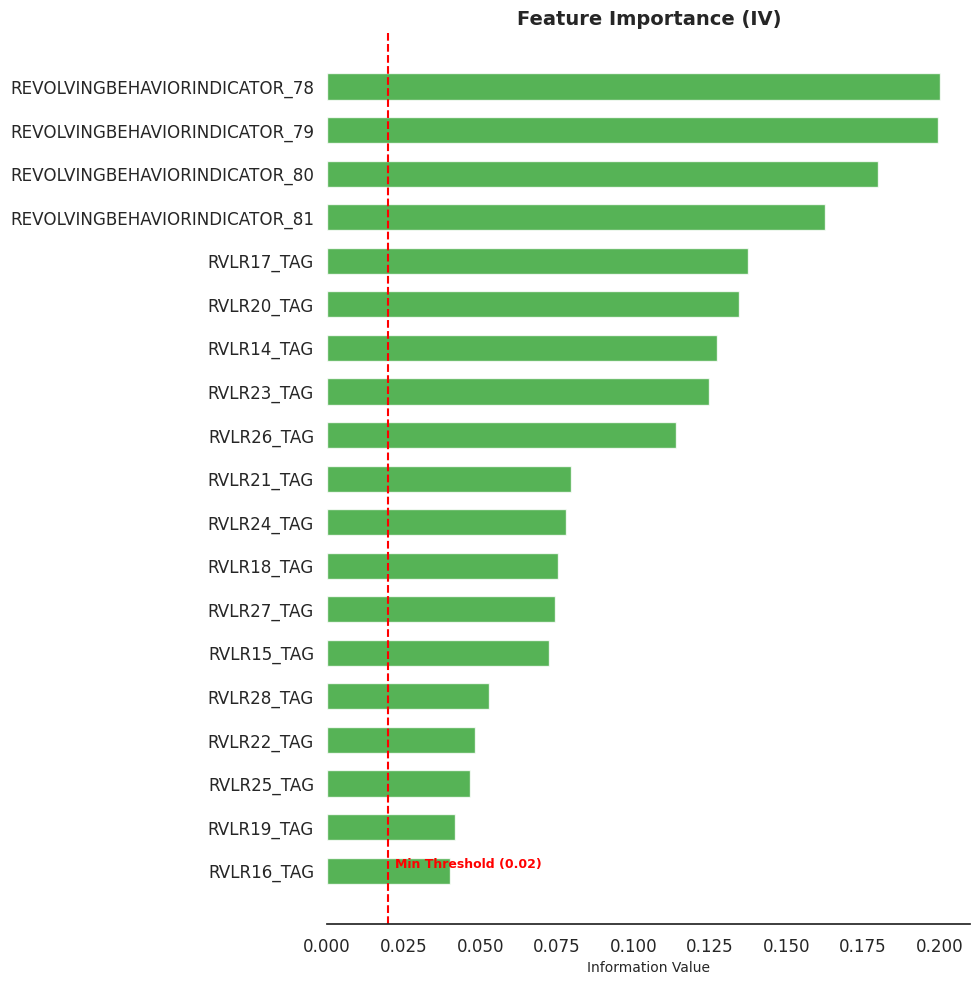

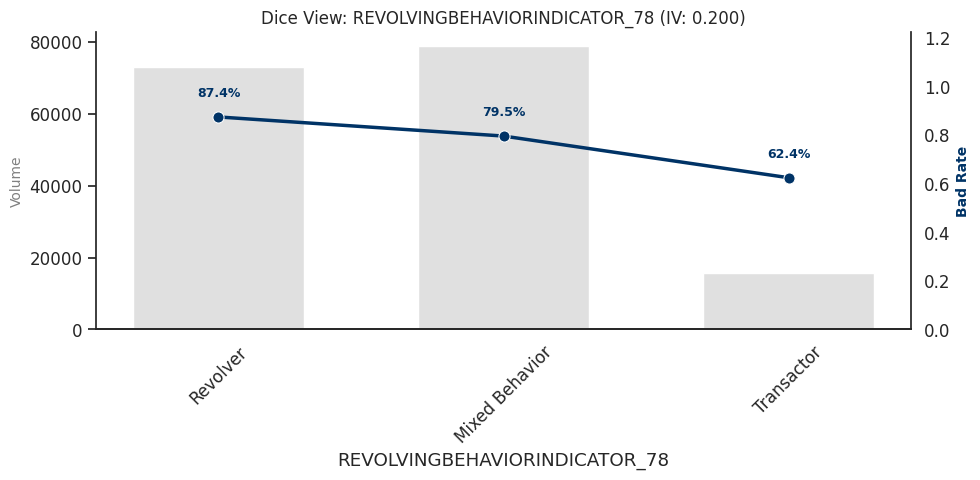

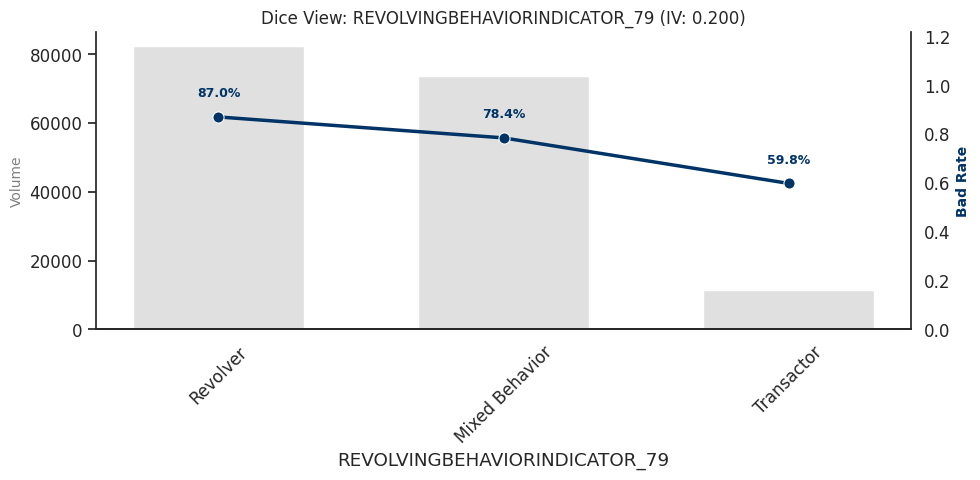

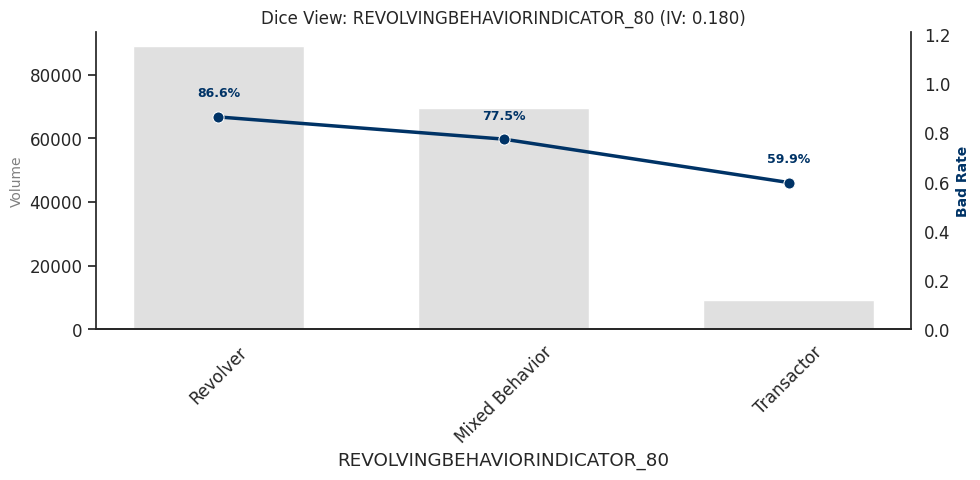

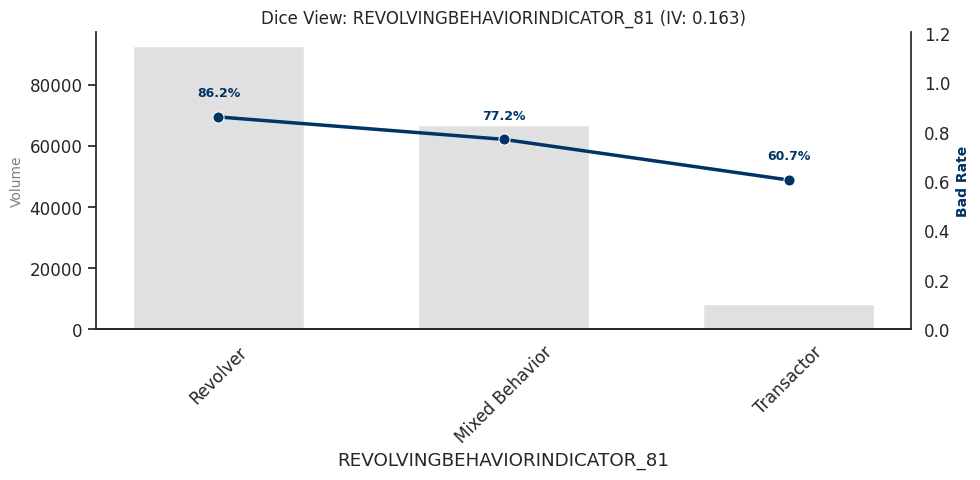

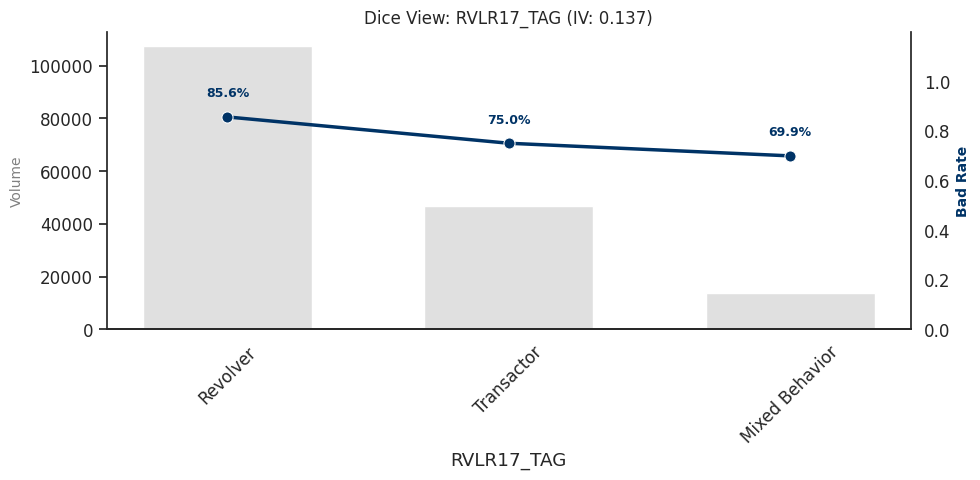

In [46]:
drop_list = [col for col in df.columns if  'pmic' in col.lower() or 'band' in col.lower()]
drop_list.extend(([col for col in df.columns if 'SUPPRE' in col]))
drop_list.extend(([col for col in df.columns if 'VINTAGE' in col]))
drop_list.extend(([col for col in df.columns if 'AUATTR' in col]))
drop_list.extend(['CCFLOW', 'PRICETESTSEGMENT','BOOKMONTH','REVOLVERFLAGFINAL'])
if __name__ == "__main__":

    # Run Analysis
    df_final_m11_2023, iv_stats = run_woe_pipeline(
         clean_df_m11_2023 ,
        target=TARGET_VAR,
        ignore_cols= drop_list
    )

    plot_results(clean_df_m11_2023, iv_stats, TARGET_VAR)

 [REPORT] Initial Non-Numeric Variables Detected: 20
   [SKIP] REVOLVERFLAGFINAL (Manually ignored)
------------------------------------------------------------
 [REPORT] Summary:
   - Total Non-Numeric Inputs : 20
   - Successfully Calculated  : 19
   - Skipped/Ignored          : 1
------------------------------------------------------------


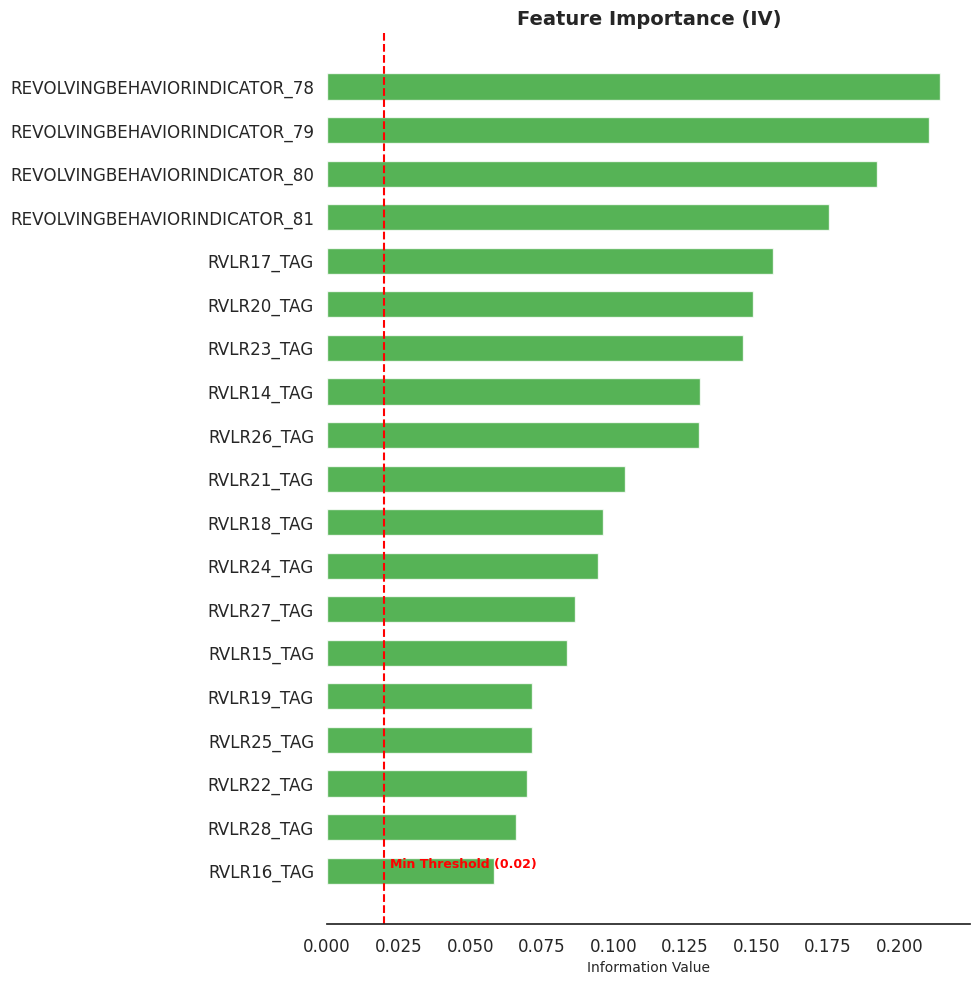

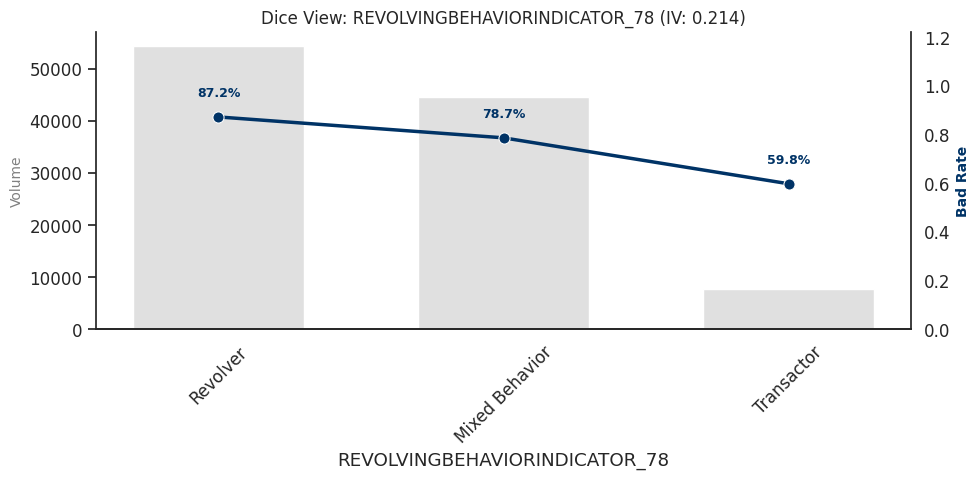

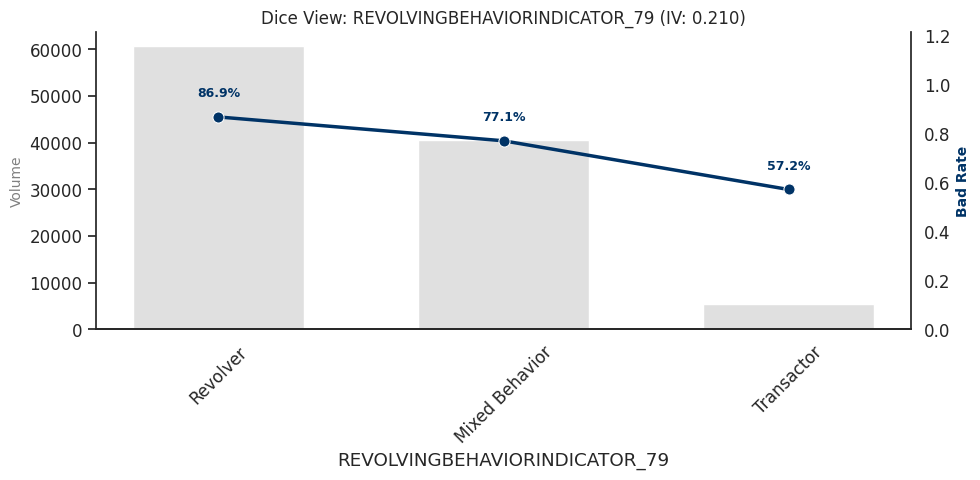

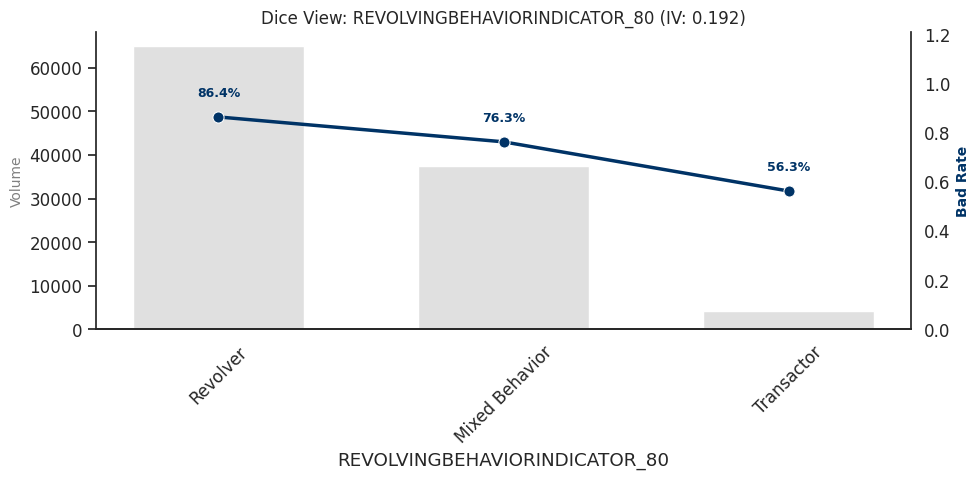

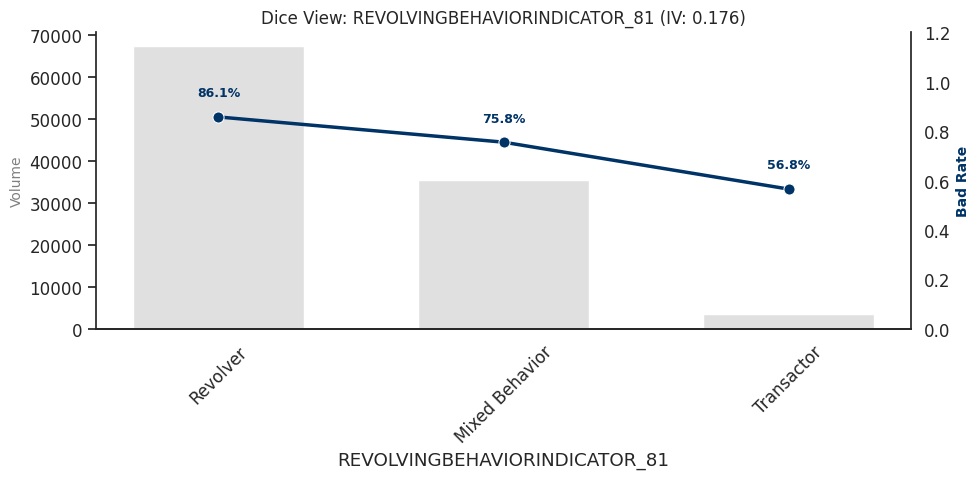

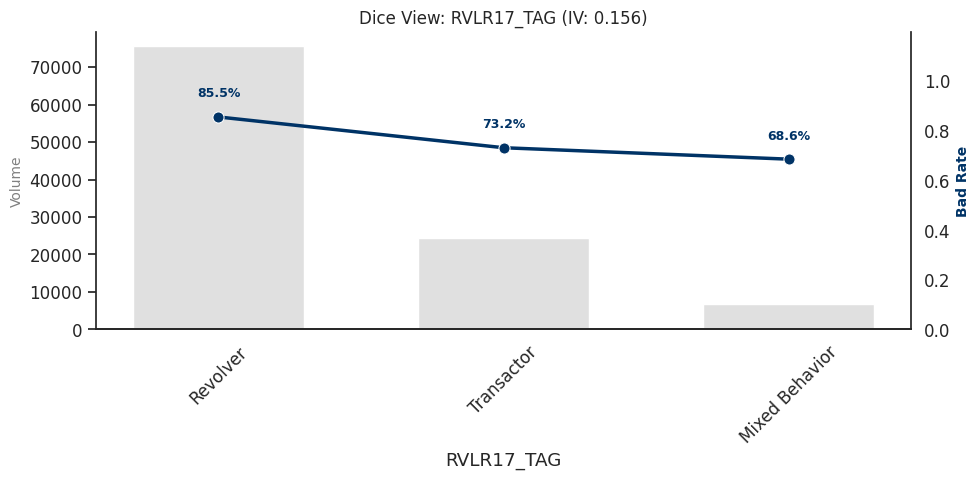

In [47]:
drop_list = [col for col in df.columns if  'pmic' in col.lower() or 'band' in col.lower()]
drop_list.extend(([col for col in df.columns if 'SUPPRE' in col]))
drop_list.extend(([col for col in df.columns if 'VINTAGE' in col]))
drop_list.extend(([col for col in df.columns if 'AUATTR' in col]))
drop_list.extend(['CCFLOW', 'PRICETESTSEGMENT','BOOKMONTH','REVOLVERFLAGFINAL'])
if __name__ == "__main__":

    # Run Analysis
    df_final_m11_2024, iv_stats = run_woe_pipeline(
         clean_df_m11_2024 ,
        target=TARGET_VAR,
        ignore_cols= drop_list
    )

    plot_results(clean_df_m11_2024, iv_stats, TARGET_VAR)

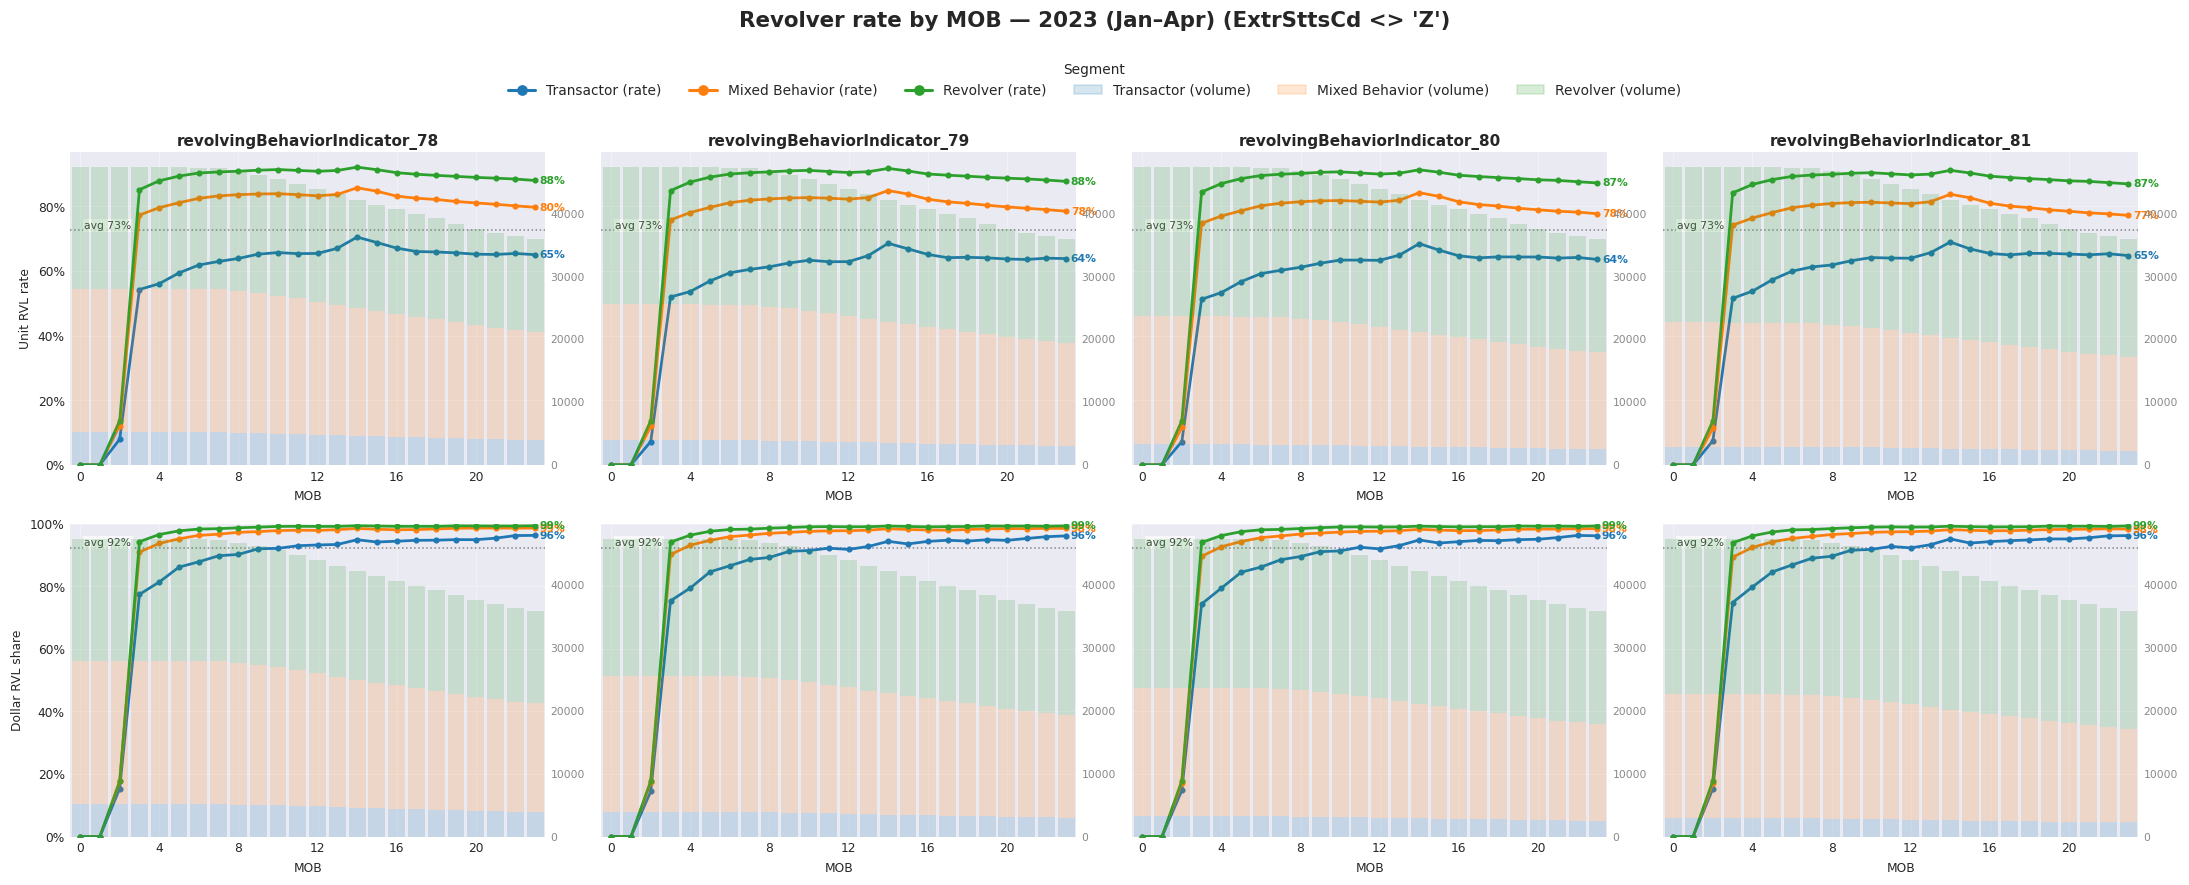

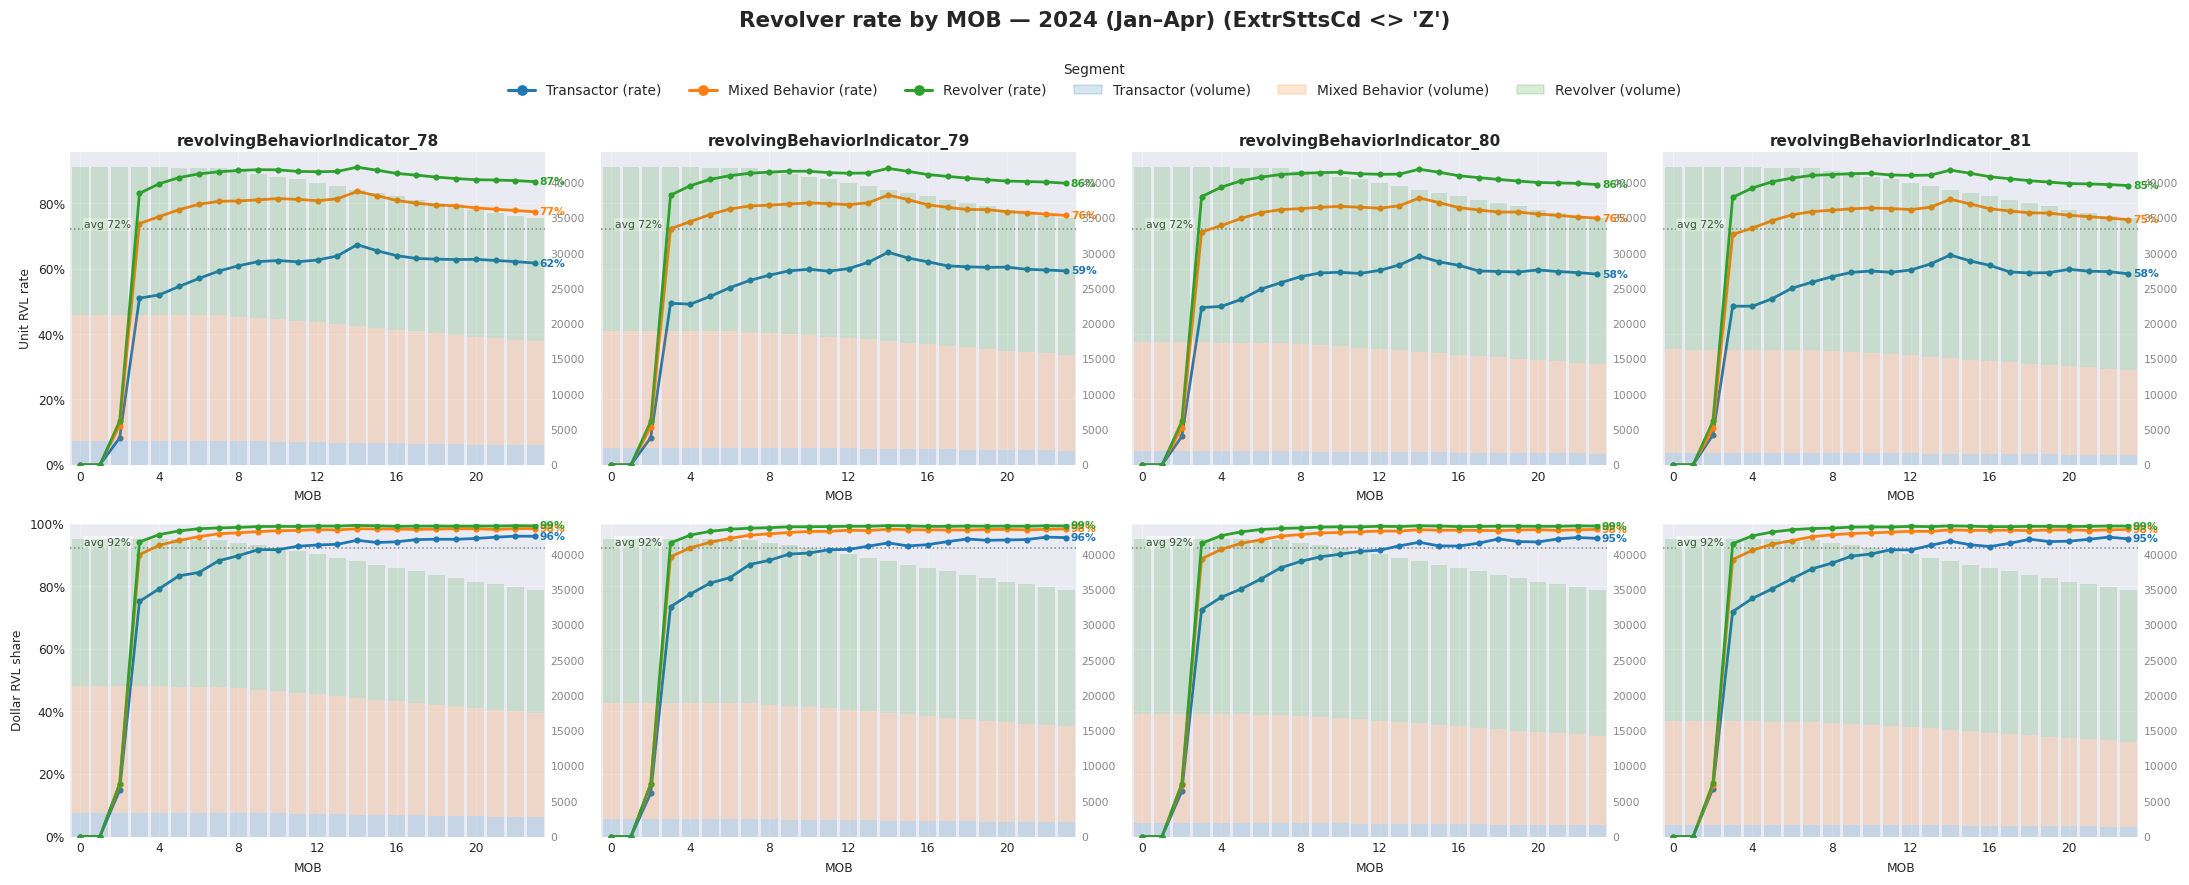

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- config ---
RVL_LIST = [
  
    "revolvingBehaviorIndicator_78",
    "revolvingBehaviorIndicator_79",
      "revolvingBehaviorIndicator_80",
    "revolvingBehaviorIndicator_81",
]
VINTAGES = [
    ("2023-01", "2023-04", "2023 (Jan–Apr)"),
    ("2024-01", "2024-04", "2024 (Jan–Apr)"),
]
SUM_COLS = ["RVL_UNIT", "TOT_NZ_UNIT", "TOT_RVL_Dollar", "TOT_NZ_Dollar"]
COLORS = plt.get_cmap("tab10").colors
LEVEL_ORDER = ["Transactor", "Mixed Behavior", "Revolver"]   # stacking order (bottom -> top)
BAR_ALPHA = 0.18


def aggregate(df, var):
    g = df.groupby(["MOB", var], observed=True, sort=False)[SUM_COLS].sum().reset_index()
    g = g.rename(columns={var: "level"})
    g["unit_rate"]   = g["RVL_UNIT"]       / g["TOT_NZ_UNIT"]
    g["dollar_rate"] = g["TOT_RVL_Dollar"] / g["TOT_NZ_Dollar"]
    return g


def row_ylim(aggs, rate_col, pad=0.04):
    vals = pd.concat([a[rate_col] for a in aggs.values()]).dropna()
    lo, hi = float(vals.min()), float(vals.max())
    span = max(hi - lo, 0.02)
    return max(0.0, lo - pad * span - 0.01), min(1.0, hi + pad * span + 0.01)


def ordered_levels(present, order=LEVEL_ORDER):
    """Keep canonical order first, then any extras alphabetically."""
    extras = sorted(p for p in present if p not in order)
    return [l for l in order if l in present] + extras


def draw_panel(ax, agg, rate_col, weight_col, title, ylabel, color_map, ylim):
    ax.set_title(title, fontsize=10, fontweight="semibold", pad=4)
    ax.set_xlabel("MOB", fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlim(-0.5, 23.5); ax.set_xticks(range(0, 24, 4))
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
    for s in ("top", "right"): ax.spines[s].set_visible(False)

    # ---- Stacked volume bars (TOT_NZ_UNIT) by behavior segment ----
    pv = (agg.pivot_table(index="MOB", columns="level",
                          values="TOT_NZ_UNIT", aggfunc="sum", fill_value=0)
              .reindex(range(0, 24), fill_value=0))
    levels_in_panel = ordered_levels(pv.columns.tolist())

    ax2 = ax.twinx()
    bottom = np.zeros(len(pv))
    for lev in levels_in_panel:
        vals = pv[lev].to_numpy(dtype=float)
        ax2.bar(pv.index, vals, bottom=bottom, color=color_map[lev],
                alpha=BAR_ALPHA, width=0.85, edgecolor="none", zorder=1)
        bottom += vals
    ax2.tick_params(axis="y", labelsize=7, colors="#888")
    ax2.grid(False); ax2.spines["top"].set_visible(False)

    # ---- Volume-weighted average rate line ----
    w = agg[weight_col]
    avg = float((agg[rate_col] * w).sum() / w.sum())
    ax.axhline(avg, color="#444", ls=":", lw=1, alpha=0.6)
    ax.text(0.2, avg, f"avg {avg:.0%}", color="#444", fontsize=7,
            va="bottom", ha="left",
            bbox=dict(facecolor="white", edgecolor="none", pad=1, alpha=0.7))

    # ---- Rate lines per segment ----
    for lev in levels_in_panel:
        sub = agg.loc[agg["level"] == lev].sort_values("MOB")
        if sub.empty:
            continue
        c = color_map[lev]
        ax.plot(sub["MOB"], sub[rate_col], marker="o", ms=3, lw=1.8, color=c, label=lev, zorder=5)
        last = sub.iloc[-1]
        ax.annotate(f"{last[rate_col]:.0%}",
                    xy=(last["MOB"], last[rate_col]),
                    xytext=(3, 0), textcoords="offset points",
                    fontsize=7, color=c, fontweight="bold", va="center")


def plot_year_dashboard(df_year, year_label):
    aggs = {var: aggregate(df_year, var) for var in RVL_LIST}
    levels = ordered_levels({lvl for a in aggs.values() for lvl in a["level"].unique()})
    color_map = {lvl: COLORS[i % len(COLORS)] for i, lvl in enumerate(levels)}

    ylim_unit   = row_ylim(aggs, "unit_rate")
    ylim_dollar = row_ylim(aggs, "dollar_rate")

    fig, axes = plt.subplots(2, 4, figsize=(20, 8), dpi=110, sharey="row")
    fig.suptitle(f"Revolver rate by MOB — {year_label} (ExtrSttsCd <> 'Z')",
                 fontsize=14, fontweight="bold", y=1.0)

    for col, var in enumerate(RVL_LIST):
        draw_panel(axes[0, col], aggs[var], "unit_rate",   "TOT_NZ_UNIT",
                   title=var, ylabel="Unit RVL rate" if col == 0 else "",
                   color_map=color_map, ylim=ylim_unit)
        draw_panel(axes[1, col], aggs[var], "dollar_rate", "TOT_NZ_Dollar",
                   title="", ylabel="Dollar RVL share" if col == 0 else "",
                   color_map=color_map, ylim=ylim_dollar)

    # Single combined legend: solid line = rate, faint square = stacked volume
    handles = []
    for l in levels:
        handles.append(plt.Line2D([0], [0], color=color_map[l], marker="o",
                                  lw=2, label=f"{l} (rate)"))
    for l in levels:
        handles.append(plt.Rectangle((0, 0), 1, 1, color=color_map[l],
                                     alpha=BAR_ALPHA, label=f"{l} (volume)"))
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.955),
               ncol=min(len(handles), 6), frameon=False, fontsize=9,
               title="Segment", title_fontsize=9)

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


# --- run ---
agg_df_nz = agg_df.loc[agg_df["ExtrSttsCd"] != "Z"].copy()
agg_df_nz[SUM_COLS] = agg_df_nz[SUM_COLS].apply(pd.to_numeric, errors="coerce")

bm = pd.to_datetime(agg_df_nz["bookmonth"]).dt.to_period("M")
keep = ["MOB", "bookmonth", *SUM_COLS, *RVL_LIST]
base = agg_df_nz.loc[agg_df_nz["MOB"].between(0, 23), keep]
base_bm = bm.loc[base.index]

for start, end, label in VINTAGES:
    df_year = base.loc[base_bm.between(pd.Period(start, "M"), pd.Period(end, "M"))]
    plot_year_dashboard(df_year, label)

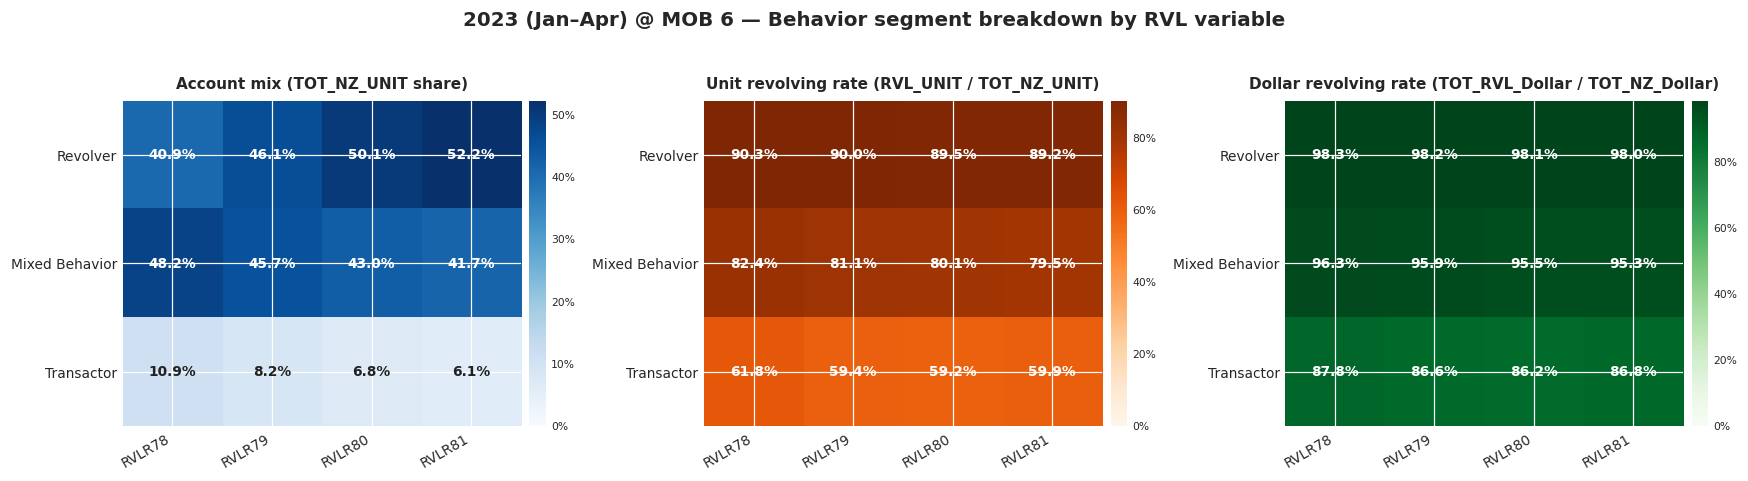

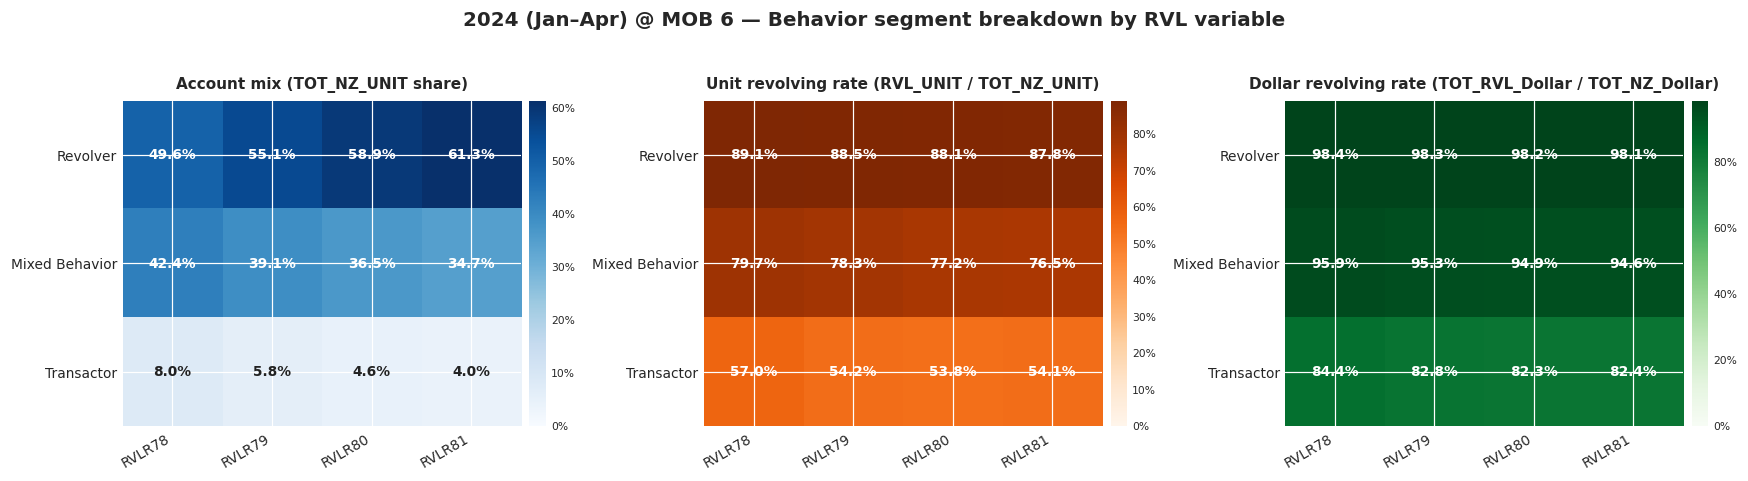

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ---------- config ----------
RVL_LIST = [
 
    "revolvingBehaviorIndicator_78",
    "revolvingBehaviorIndicator_79",
       "revolvingBehaviorIndicator_80",
    "revolvingBehaviorIndicator_81",
]
VINTAGES = [
    ("2023-01", "2023-04", "2023 (Jan–Apr)"),
    ("2024-01", "2024-04", "2024 (Jan–Apr)"),
]
LEVEL_ORDER  = ["Revolver", "Mixed Behavior", "Transactor"]
SHORT_VARS   = {v: v.replace("revolvingBehaviorIndicator_", "RVLR") for v in RVL_LIST}
SUM_COLS     = ["RVL_UNIT", "TOT_NZ_UNIT", "TOT_RVL_Dollar", "TOT_NZ_Dollar"]
SNAPSHOT_MOB = 6


# ---------- data prep ----------
agg_df_nz = agg_df.loc[agg_df["ExtrSttsCd"] != "Z"].copy()
agg_df_nz[SUM_COLS] = agg_df_nz[SUM_COLS].apply(pd.to_numeric, errors="coerce")

bm   = pd.to_datetime(agg_df_nz["bookmonth"]).dt.to_period("M")
keep = ["MOB", "bookmonth", *SUM_COLS, *RVL_LIST]
base = agg_df_nz.loc[agg_df_nz["MOB"].between(0, 23), keep]
base_bm = bm.loc[base.index]


# ---------- metrics ----------
def seg_metrics(df_slice, var):
    """Mirrors aggregate() math, collapsed to a single MOB → one row per segment."""
    g = df_slice.groupby(var, observed=True)[SUM_COLS].sum()
    total_units = float(g["TOT_NZ_UNIT"].sum())
    g["acct_mix"]    = g["TOT_NZ_UNIT"] / total_units if total_units > 0 else np.nan
    g["unit_rate"]   = g["RVL_UNIT"]       / g["TOT_NZ_UNIT"].replace(0, np.nan)
    g["dollar_rate"] = g["TOT_RVL_Dollar"] / g["TOT_NZ_Dollar"].replace(0, np.nan)
    return g


def build_tables(df_slice):
    """3 tables: rows=segments, cols=RVL vars."""
    acct   = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)
    unit   = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)
    dollar = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)

    for var in RVL_LIST:
        m = seg_metrics(df_slice, var)
        for lev in LEVEL_ORDER:
            acct.loc[lev, var]   = m["acct_mix"].get(lev,    np.nan)
            unit.loc[lev, var]   = m["unit_rate"].get(lev,   np.nan)
            dollar.loc[lev, var] = m["dollar_rate"].get(lev, np.nan)

    acct.columns = unit.columns = dollar.columns = [SHORT_VARS[c] for c in acct.columns]
    return {
        "Account mix (TOT_NZ_UNIT share)":                        acct,
        "Unit revolving rate (RVL_UNIT / TOT_NZ_UNIT)":           unit,
        "Dollar revolving rate (TOT_RVL_Dollar / TOT_NZ_Dollar)": dollar,
    }


# ---------- viz ----------
def plot_heatmaps(tables, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=110)
    cmaps = ["Blues", "Oranges", "Greens"]

    for ax, (cap, df), cmap in zip(axes, tables.items(), cmaps):
        vals = df.to_numpy(dtype=float)
        vmax = np.nanmax(vals) if np.isfinite(np.nanmax(vals)) else 1.0
        im = ax.imshow(vals, cmap=cmap, vmin=0, vmax=vmax, aspect="auto")

        ax.set_xticks(range(df.shape[1]))
        ax.set_xticklabels(df.columns, rotation=30, ha="right", fontsize=9)
        ax.set_yticks(range(df.shape[0]))
        ax.set_yticklabels(df.index, fontsize=9)
        ax.set_title(cap, fontsize=10, fontweight="semibold", pad=8)
        for s in ("top", "right", "bottom", "left"):
            ax.spines[s].set_visible(False)
        ax.tick_params(length=0)

        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                v = vals[i, j]
                if np.isnan(v):
                    continue
                txt_color = "white" if v > 0.55 * vmax else "#222"
                ax.text(j, i, f"{v:.1%}", ha="center", va="center",
                        fontsize=9, color=txt_color, fontweight="semibold")

        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle(f"{title} — Behavior segment breakdown by RVL variable",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    plt.show()


# ---------- run ----------
for start, end, label in VINTAGES:
    df_slice = base.loc[
        base_bm.between(pd.Period(start, "M"), pd.Period(end, "M"))
        & (base["MOB"] == SNAPSHOT_MOB)
    ]
    plot_heatmaps(build_tables(df_slice), f"{label} @ MOB {SNAPSHOT_MOB}")

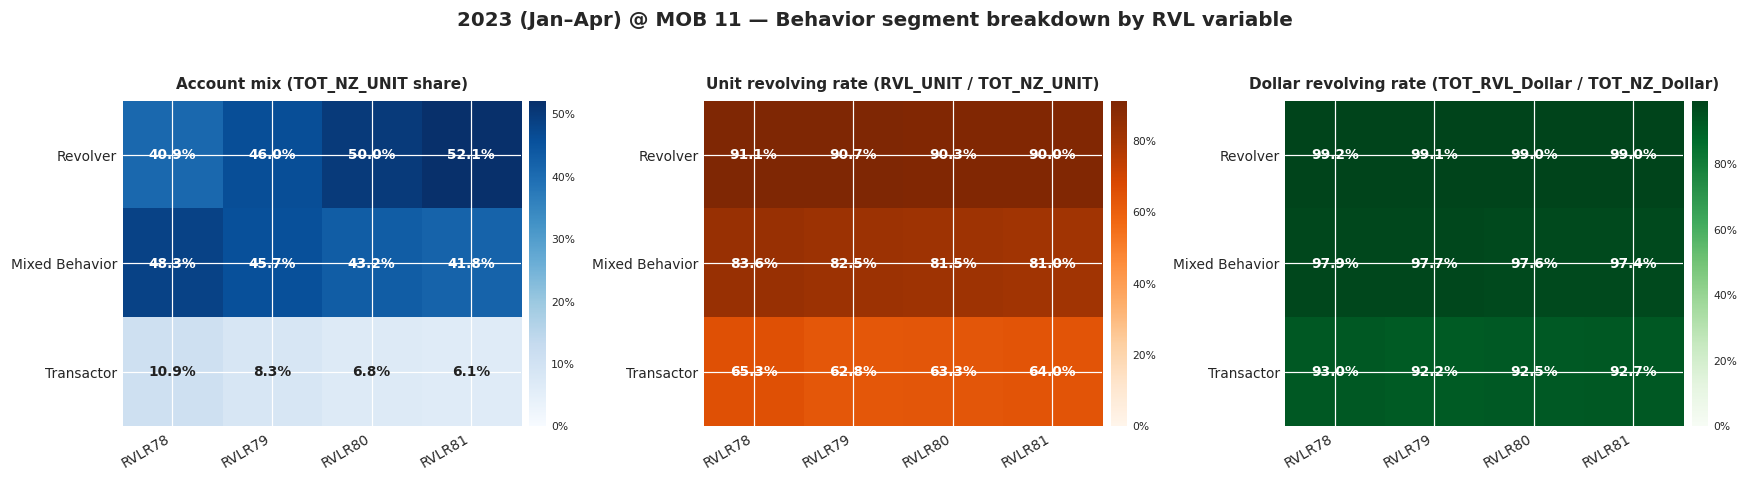

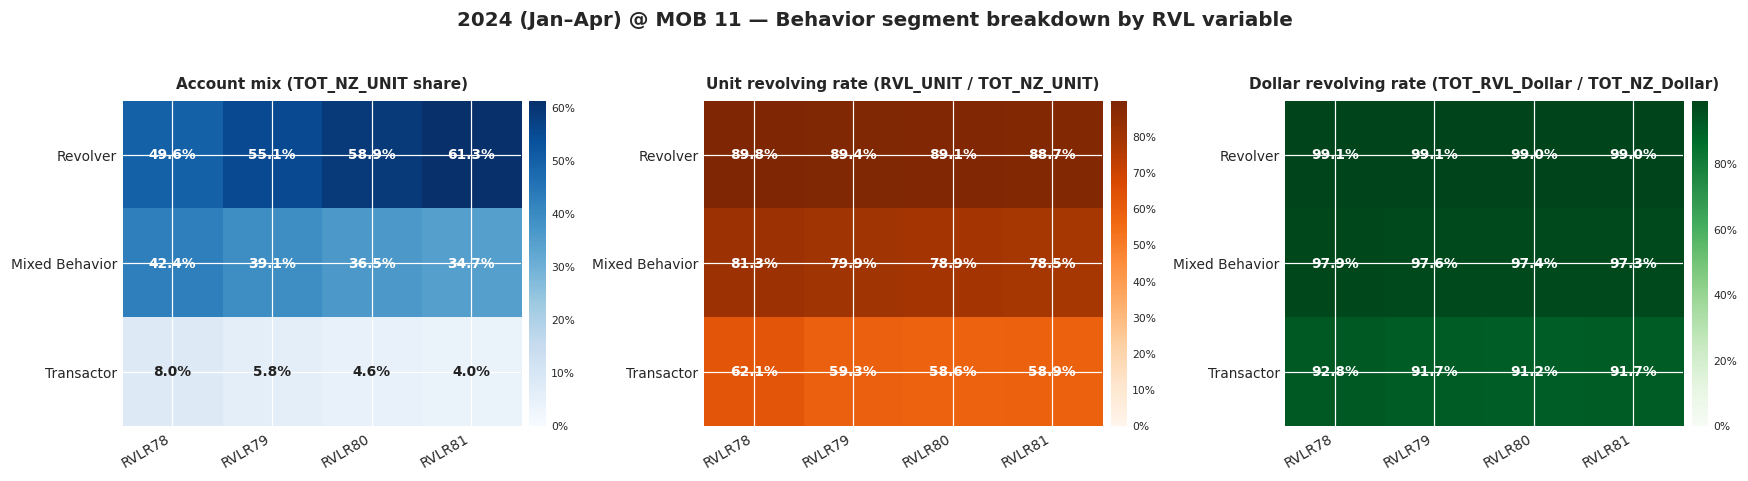

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ---------- config ----------
RVL_LIST = [
 
    "revolvingBehaviorIndicator_78",
    "revolvingBehaviorIndicator_79",
       "revolvingBehaviorIndicator_80",
    "revolvingBehaviorIndicator_81",
]
VINTAGES = [
    ("2023-01", "2023-04", "2023 (Jan–Apr)"),
    ("2024-01", "2024-04", "2024 (Jan–Apr)"),
]
LEVEL_ORDER  = ["Revolver", "Mixed Behavior", "Transactor"]
SHORT_VARS   = {v: v.replace("revolvingBehaviorIndicator_", "RVLR") for v in RVL_LIST}
SUM_COLS     = ["RVL_UNIT", "TOT_NZ_UNIT", "TOT_RVL_Dollar", "TOT_NZ_Dollar"]
SNAPSHOT_MOB = 11


# ---------- data prep ----------
agg_df_nz = agg_df.loc[agg_df["ExtrSttsCd"] != "Z"].copy()
agg_df_nz[SUM_COLS] = agg_df_nz[SUM_COLS].apply(pd.to_numeric, errors="coerce")

bm   = pd.to_datetime(agg_df_nz["bookmonth"]).dt.to_period("M")
keep = ["MOB", "bookmonth", *SUM_COLS, *RVL_LIST]
base = agg_df_nz.loc[agg_df_nz["MOB"].between(0, 23), keep]
base_bm = bm.loc[base.index]


# ---------- metrics ----------
def seg_metrics(df_slice, var):
    """Mirrors aggregate() math, collapsed to a single MOB → one row per segment."""
    g = df_slice.groupby(var, observed=True)[SUM_COLS].sum()
    total_units = float(g["TOT_NZ_UNIT"].sum())
    g["acct_mix"]    = g["TOT_NZ_UNIT"] / total_units if total_units > 0 else np.nan
    g["unit_rate"]   = g["RVL_UNIT"]       / g["TOT_NZ_UNIT"].replace(0, np.nan)
    g["dollar_rate"] = g["TOT_RVL_Dollar"] / g["TOT_NZ_Dollar"].replace(0, np.nan)
    return g


def build_tables(df_slice):
    """3 tables: rows=segments, cols=RVL vars."""
    acct   = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)
    unit   = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)
    dollar = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)

    for var in RVL_LIST:
        m = seg_metrics(df_slice, var)
        for lev in LEVEL_ORDER:
            acct.loc[lev, var]   = m["acct_mix"].get(lev,    np.nan)
            unit.loc[lev, var]   = m["unit_rate"].get(lev,   np.nan)
            dollar.loc[lev, var] = m["dollar_rate"].get(lev, np.nan)

    acct.columns = unit.columns = dollar.columns = [SHORT_VARS[c] for c in acct.columns]
    return {
        "Account mix (TOT_NZ_UNIT share)":                        acct,
        "Unit revolving rate (RVL_UNIT / TOT_NZ_UNIT)":           unit,
        "Dollar revolving rate (TOT_RVL_Dollar / TOT_NZ_Dollar)": dollar,
    }


# ---------- viz ----------
def plot_heatmaps(tables, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=110)
    cmaps = ["Blues", "Oranges", "Greens"]

    for ax, (cap, df), cmap in zip(axes, tables.items(), cmaps):
        vals = df.to_numpy(dtype=float)
        vmax = np.nanmax(vals) if np.isfinite(np.nanmax(vals)) else 1.0
        im = ax.imshow(vals, cmap=cmap, vmin=0, vmax=vmax, aspect="auto")

        ax.set_xticks(range(df.shape[1]))
        ax.set_xticklabels(df.columns, rotation=30, ha="right", fontsize=9)
        ax.set_yticks(range(df.shape[0]))
        ax.set_yticklabels(df.index, fontsize=9)
        ax.set_title(cap, fontsize=10, fontweight="semibold", pad=8)
        for s in ("top", "right", "bottom", "left"):
            ax.spines[s].set_visible(False)
        ax.tick_params(length=0)

        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                v = vals[i, j]
                if np.isnan(v):
                    continue
                txt_color = "white" if v > 0.55 * vmax else "#222"
                ax.text(j, i, f"{v:.1%}", ha="center", va="center",
                        fontsize=9, color=txt_color, fontweight="semibold")

        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle(f"{title} — Behavior segment breakdown by RVL variable",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    plt.show()


# ---------- run ----------
for start, end, label in VINTAGES:
    df_slice = base.loc[
        base_bm.between(pd.Period(start, "M"), pd.Period(end, "M"))
        & (base["MOB"] == SNAPSHOT_MOB)
    ]
    plot_heatmaps(build_tables(df_slice), f"{label} @ MOB {SNAPSHOT_MOB}")

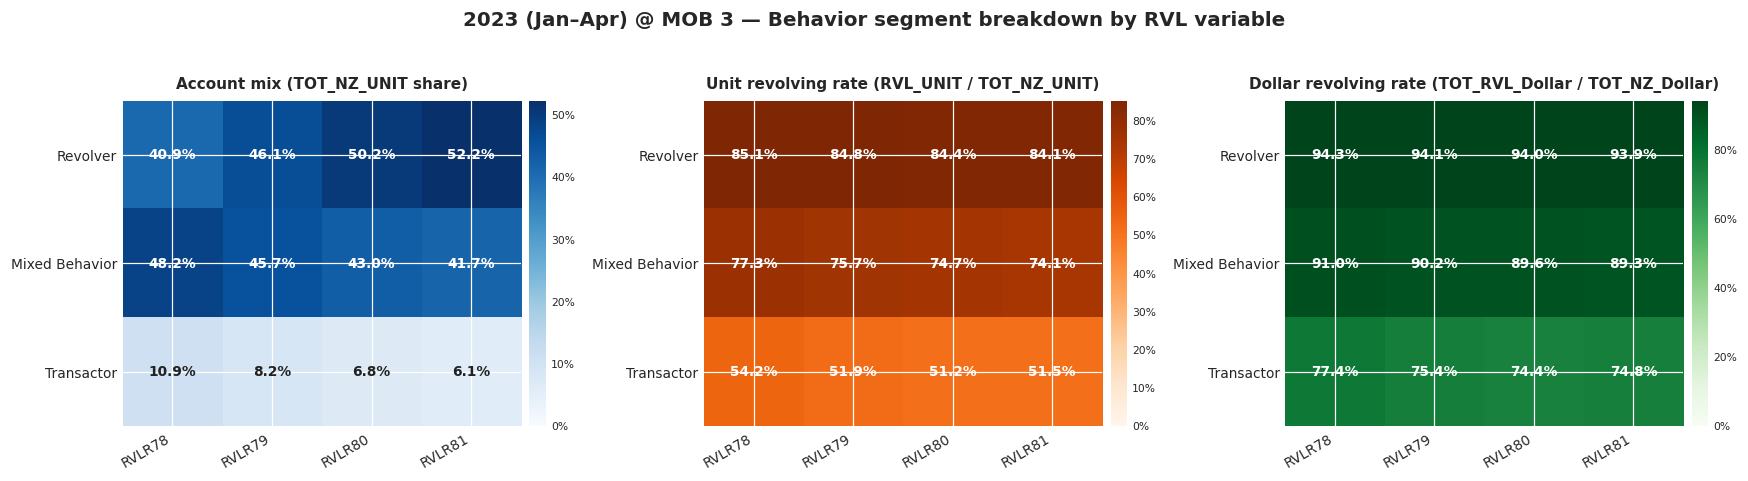

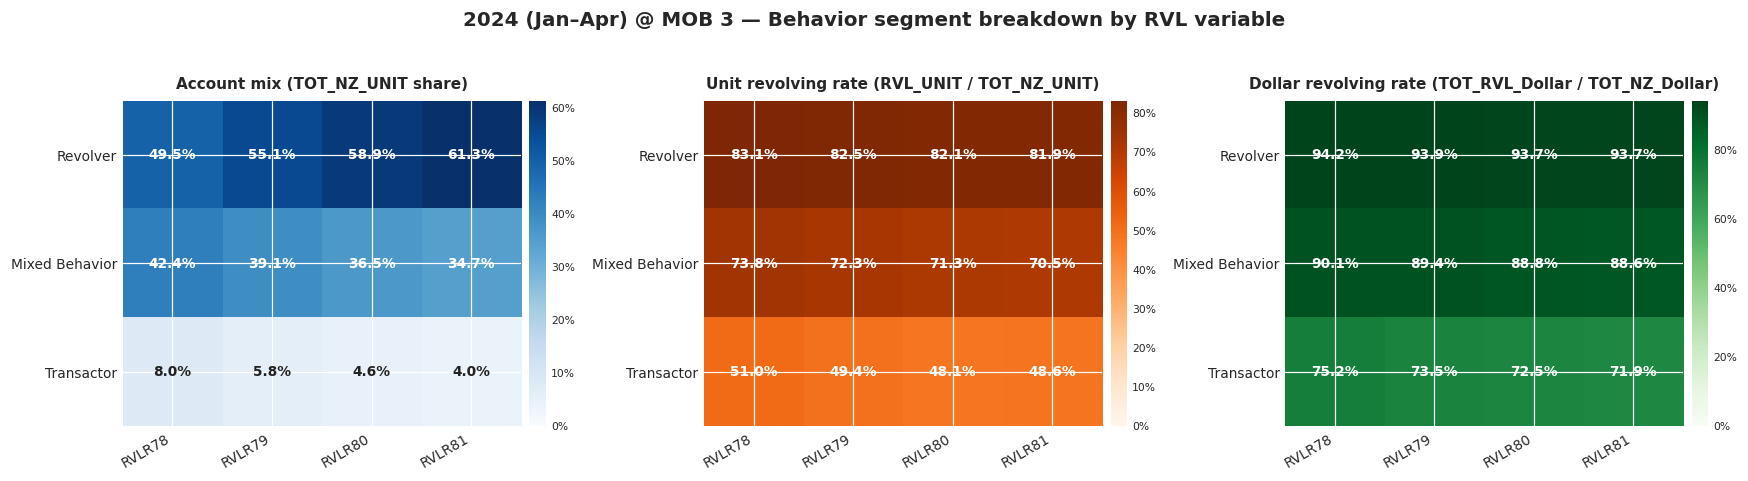

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ---------- config ----------
RVL_LIST = [
 
    "revolvingBehaviorIndicator_78",
    "revolvingBehaviorIndicator_79",
       "revolvingBehaviorIndicator_80",
    "revolvingBehaviorIndicator_81",
]
VINTAGES = [
    ("2023-01", "2023-04", "2023 (Jan–Apr)"),
    ("2024-01", "2024-04", "2024 (Jan–Apr)"),
]
LEVEL_ORDER  = ["Revolver", "Mixed Behavior", "Transactor"]
SHORT_VARS   = {v: v.replace("revolvingBehaviorIndicator_", "RVLR") for v in RVL_LIST}
SUM_COLS     = ["RVL_UNIT", "TOT_NZ_UNIT", "TOT_RVL_Dollar", "TOT_NZ_Dollar"]
SNAPSHOT_MOB = 3


# ---------- data prep ----------
agg_df_nz = agg_df.loc[agg_df["ExtrSttsCd"] != "Z"].copy()
agg_df_nz[SUM_COLS] = agg_df_nz[SUM_COLS].apply(pd.to_numeric, errors="coerce")

bm   = pd.to_datetime(agg_df_nz["bookmonth"]).dt.to_period("M")
keep = ["MOB", "bookmonth", *SUM_COLS, *RVL_LIST]
base = agg_df_nz.loc[agg_df_nz["MOB"].between(0, 23), keep]
base_bm = bm.loc[base.index]


# ---------- metrics ----------
def seg_metrics(df_slice, var):
    """Mirrors aggregate() math, collapsed to a single MOB → one row per segment."""
    g = df_slice.groupby(var, observed=True)[SUM_COLS].sum()
    total_units = float(g["TOT_NZ_UNIT"].sum())
    g["acct_mix"]    = g["TOT_NZ_UNIT"] / total_units if total_units > 0 else np.nan
    g["unit_rate"]   = g["RVL_UNIT"]       / g["TOT_NZ_UNIT"].replace(0, np.nan)
    g["dollar_rate"] = g["TOT_RVL_Dollar"] / g["TOT_NZ_Dollar"].replace(0, np.nan)
    return g


def build_tables(df_slice):
    """3 tables: rows=segments, cols=RVL vars."""
    acct   = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)
    unit   = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)
    dollar = pd.DataFrame(index=LEVEL_ORDER, columns=RVL_LIST, dtype=float)

    for var in RVL_LIST:
        m = seg_metrics(df_slice, var)
        for lev in LEVEL_ORDER:
            acct.loc[lev, var]   = m["acct_mix"].get(lev,    np.nan)
            unit.loc[lev, var]   = m["unit_rate"].get(lev,   np.nan)
            dollar.loc[lev, var] = m["dollar_rate"].get(lev, np.nan)

    acct.columns = unit.columns = dollar.columns = [SHORT_VARS[c] for c in acct.columns]
    return {
        "Account mix (TOT_NZ_UNIT share)":                        acct,
        "Unit revolving rate (RVL_UNIT / TOT_NZ_UNIT)":           unit,
        "Dollar revolving rate (TOT_RVL_Dollar / TOT_NZ_Dollar)": dollar,
    }


# ---------- viz ----------
def plot_heatmaps(tables, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), dpi=110)
    cmaps = ["Blues", "Oranges", "Greens"]

    for ax, (cap, df), cmap in zip(axes, tables.items(), cmaps):
        vals = df.to_numpy(dtype=float)
        vmax = np.nanmax(vals) if np.isfinite(np.nanmax(vals)) else 1.0
        im = ax.imshow(vals, cmap=cmap, vmin=0, vmax=vmax, aspect="auto")

        ax.set_xticks(range(df.shape[1]))
        ax.set_xticklabels(df.columns, rotation=30, ha="right", fontsize=9)
        ax.set_yticks(range(df.shape[0]))
        ax.set_yticklabels(df.index, fontsize=9)
        ax.set_title(cap, fontsize=10, fontweight="semibold", pad=8)
        for s in ("top", "right", "bottom", "left"):
            ax.spines[s].set_visible(False)
        ax.tick_params(length=0)

        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                v = vals[i, j]
                if np.isnan(v):
                    continue
                txt_color = "white" if v > 0.55 * vmax else "#222"
                ax.text(j, i, f"{v:.1%}", ha="center", va="center",
                        fontsize=9, color=txt_color, fontweight="semibold")

        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle(f"{title} — Behavior segment breakdown by RVL variable",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    plt.show()


# ---------- run ----------
for start, end, label in VINTAGES:
    df_slice = base.loc[
        base_bm.between(pd.Period(start, "M"), pd.Period(end, "M"))
        & (base["MOB"] == SNAPSHOT_MOB)
    ]
    plot_heatmaps(build_tables(df_slice), f"{label} @ MOB {SNAPSHOT_MOB}")